# FPO Previous Violation History

Regressor design & results


In [3]:
import seaborn as sns
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype


from violmulti.data.dataset_loader import DatasetLoader
from violmulti.experiments.experiment import load_experiment
from violmulti.utils.violation_iti import *
from violmulti.visualizations.model_visualizer import *
from violmulti.models.linear_regression import *
import config as c
from violmulti.features.design_matrix_generator_PWM import *

sns.set_context("talk")

%load_ext autoreload
%autoreload 2

DATA_PATH = "/Users/jessbreda/Desktop/github/violations-multinomial/data"

prev_viol_exp = "2025_04_09_fig2_fit_prev_violation_rs47.pkl"
filt_prev_viol_exp = "2025_04_09_fig2_fit_filt_prev_violation_rs47.pkl"
compare_exp = "2025_04_09_fig2_compare_prev_viol_rs47.pkl"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Clustering


In [6]:
df = DatasetLoader().load_data() # this loads the trained data

CHOICE_ORDER = ["Left", "Violation", "Right"]
CHOICE_PAL = [c.LEFT_COLOR_FPO, c.VIOLATION_COLOR_FPO, c.RIGHT_COLOR_FPO]
ex_animal = 'W075'
ex_session = 408

ex_df = df.query("animal_id == @ex_animal and session == @ex_session").copy()


ex_df["Choice"] = ex_df["choice"].map({0: "Left", 1: "Right", 2: "Violation"})
cat_type = CategoricalDtype(
    categories=CHOICE_ORDER,
    ordered=True
)
ex_df['Choice'] = ex_df['Choice'].astype(cat_type)

ex_df.agg(
    hit_rate = ("hit", "mean"),
    violation_rate = ("violation", "mean"),
    n_trials = ("trial", "count")
)


DataLoader: Loading data for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W083', 'W088', 'W089', 'W094']


,hit,violation,trial
hit_rate,0.878378,NaN,NaN
violation_rate,NaN,0.119048,NaN
n_trials,NaN,NaN,420.0


/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_7339/3166619421.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(-10, 71, 10))


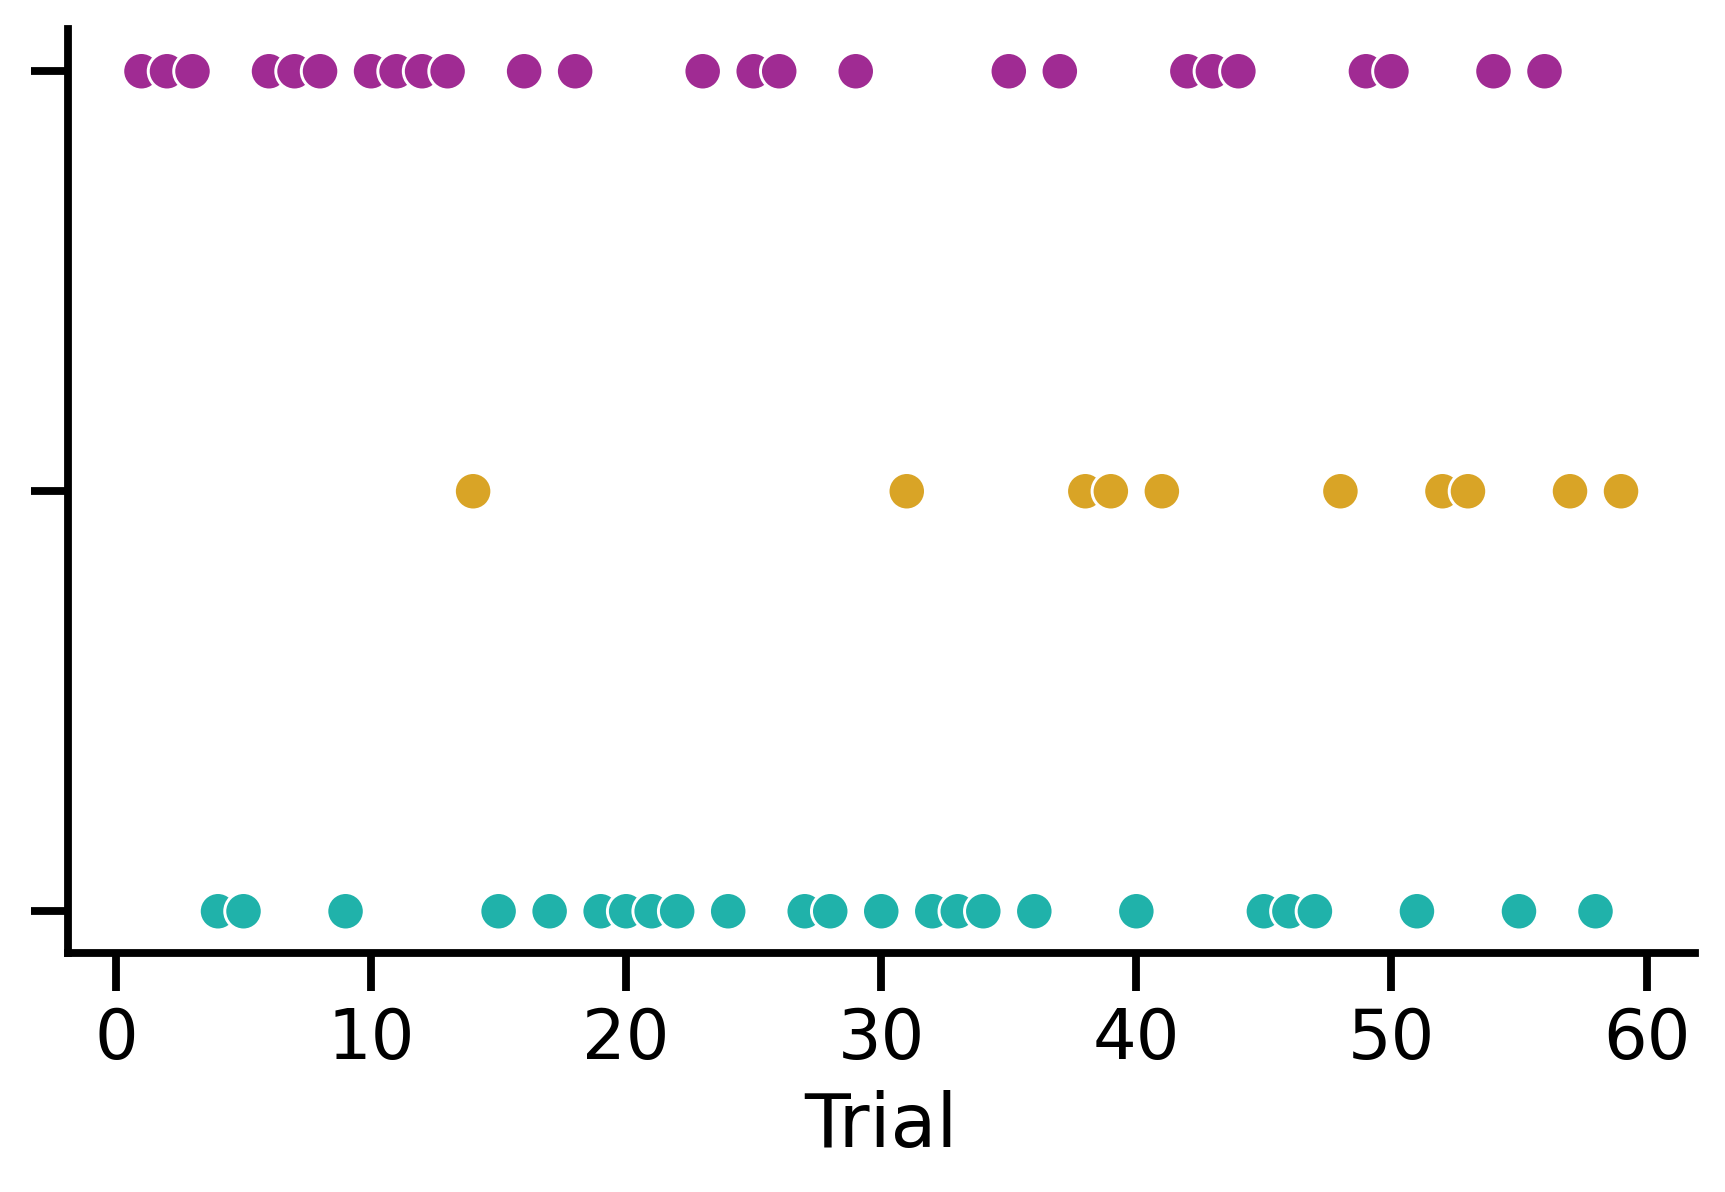

In [7]:

fig, ax = plt.subplots(figsize=(7,4), dpi=300)

sns.despine()
sns.scatterplot(
    x="trial",
    y="Choice",
    data=ex_df.query("trial > 40 and trial < 100"),
    hue="Choice",
    hue_order=CHOICE_ORDER,
    palette=CHOICE_PAL
)


ax.set_ylabel("")
ax.set_xlabel("Trial")
ax.set_yticklabels([])
# ax.set_xticks(range(0, 61, 10))
ax.set_xticklabels(range(-10, 71, 10))
ax.legend().remove()

## Autocorrelogram


In [47]:
with open('data/violation_autocorrelation_stats.pkl', 'rb') as f:
    loaded_stats = pickle.load(f)

loaded_stats.keys()

dict_keys(['observed_mean', 'confidence_intervals', 'null_distribution', 'lags', 'parameters'])

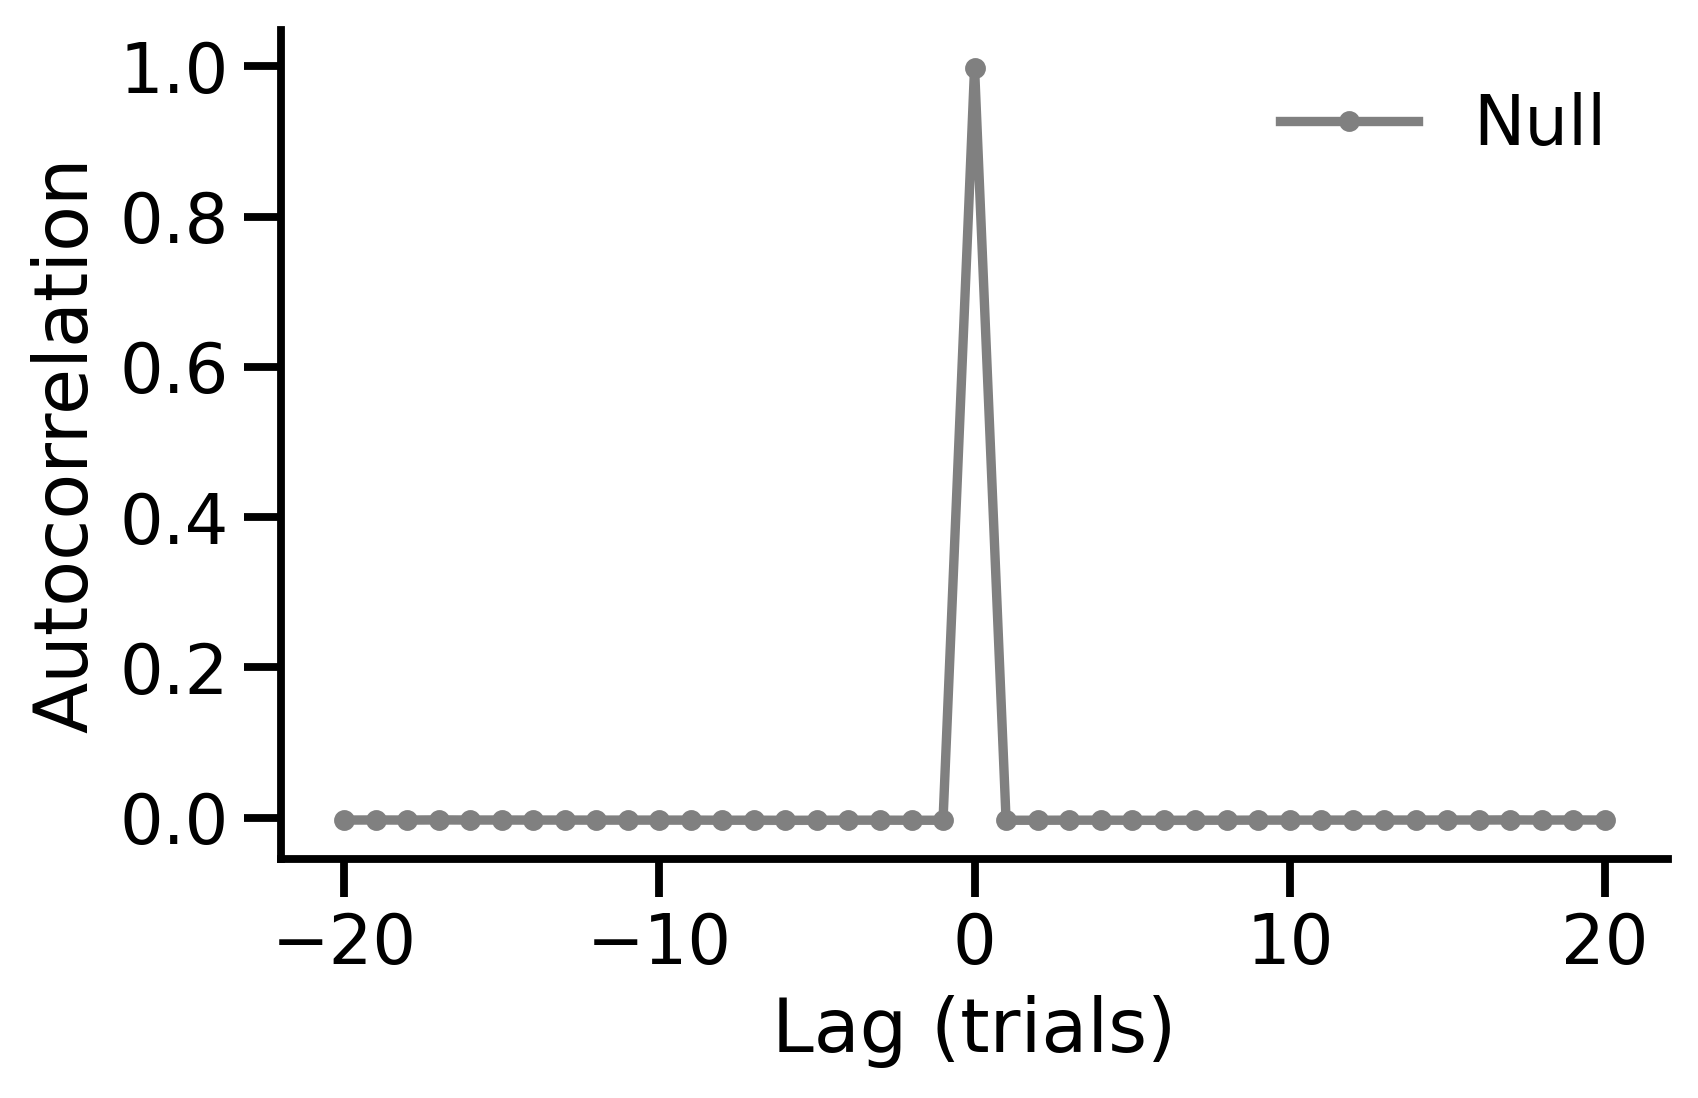

In [64]:

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

sns.despine()

# Plot the shuffled (null) distribution.
plt.plot(loaded_stats['lags'], loaded_stats['null_distribution']['mean'], label='Null', color='gray', marker="o", markersize=4)
plt.fill_between(loaded_stats['lags'], loaded_stats['null_distribution']['lower'], loaded_stats['null_distribution']['upper'], alpha=0.3, color='gray', label='')


# Decorations
plt.xlabel('Lag (trials)')
plt.ylabel('Autocorrelation')
plt.legend(frameon=False, bbox_to_anchor=(1, 1))
plt.tight_layout()


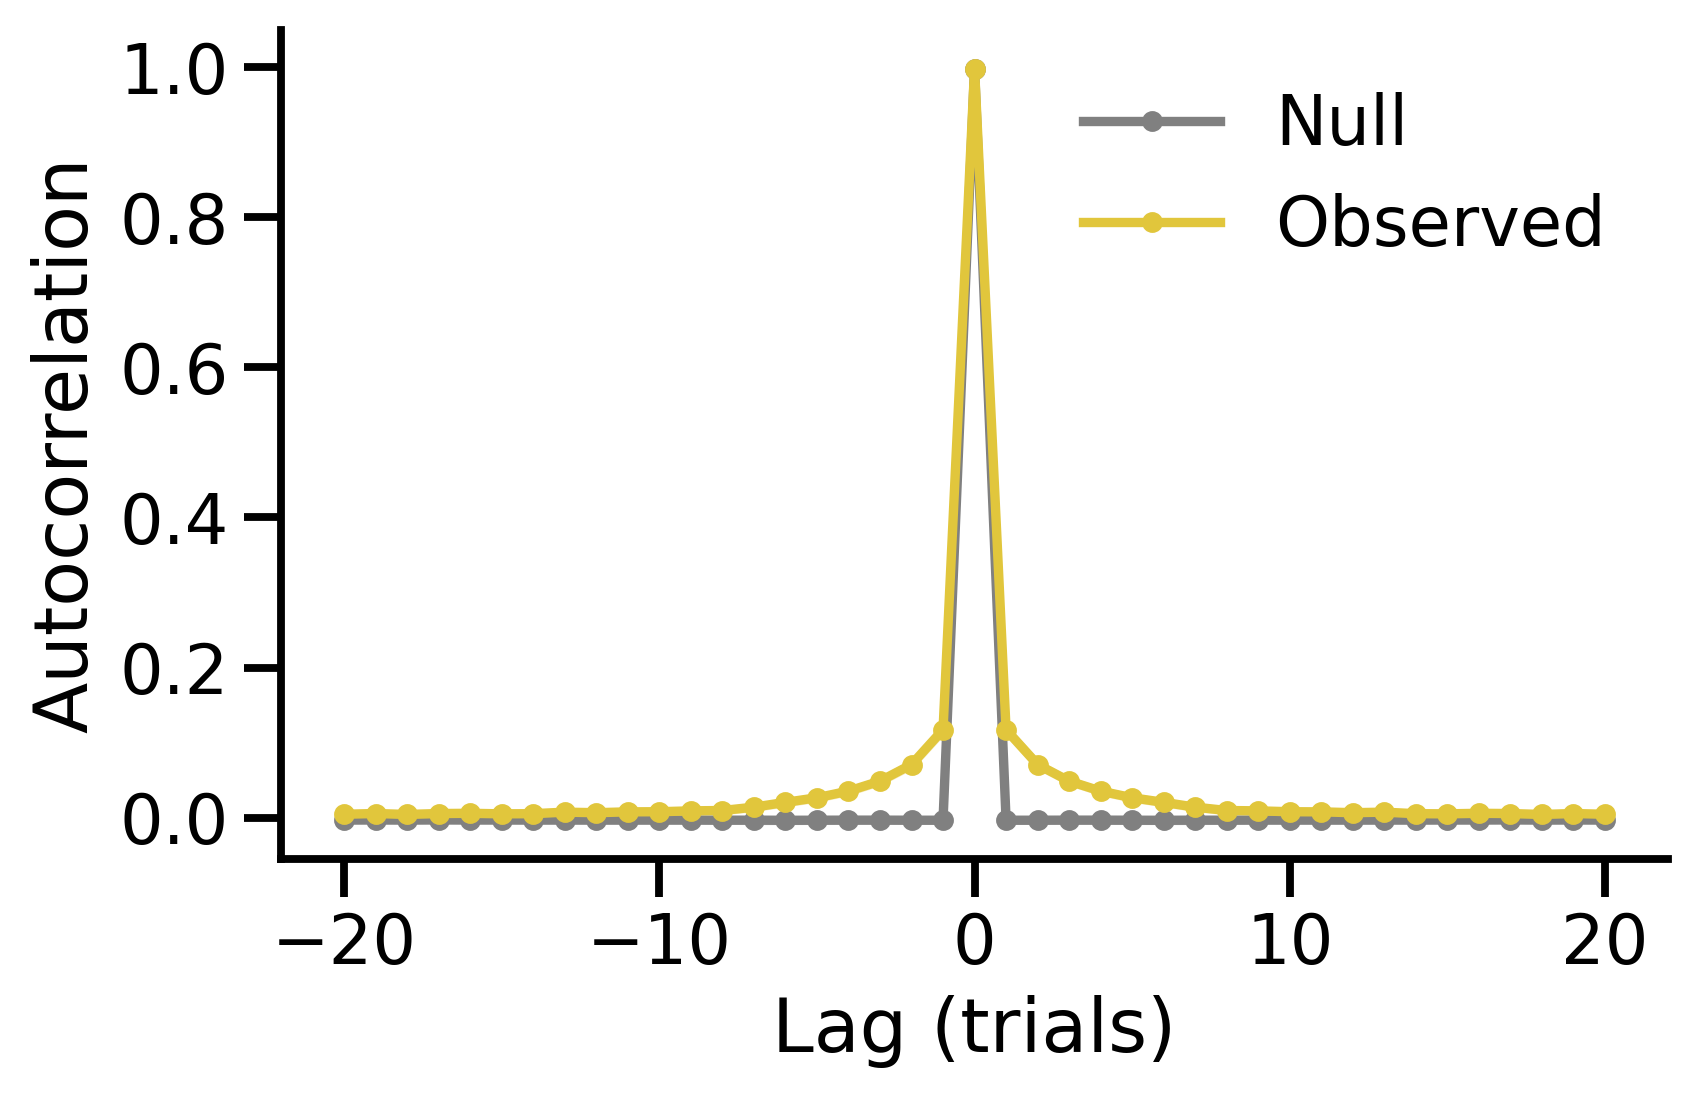

In [66]:

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

sns.despine()

# Plot the shuffled (null) distribution.
plt.plot(loaded_stats['lags'], loaded_stats['null_distribution']['mean'], label='Null', color='gray', marker="o", markersize=4)
plt.fill_between(loaded_stats['lags'], loaded_stats['null_distribution']['lower'], loaded_stats['null_distribution']['upper'], alpha=0.3, color='gray', label='')

# Plot observed autocorrelation.
plt.plot(loaded_stats['lags'], loaded_stats['observed_mean'], label='Observed', color=c.VIOLATION_COLOR_FPO, marker="o", markersize=4)
plt.fill_between(loaded_stats['lags'], loaded_stats['confidence_intervals']['lower'], loaded_stats['confidence_intervals']['upper'], alpha=0.3, color=c.VIOLATION_COLOR_FPO)


# Decorations
plt.xlabel('Lag (trials)')
plt.ylabel('Autocorrelation')
plt.legend(frameon=False, bbox_to_anchor=(1, 1))
plt.tight_layout()


## Design


In [8]:
demo_data = pd.read_csv("data/demo_intuition_data.csv")
ylim=(-0.1, 1.1)

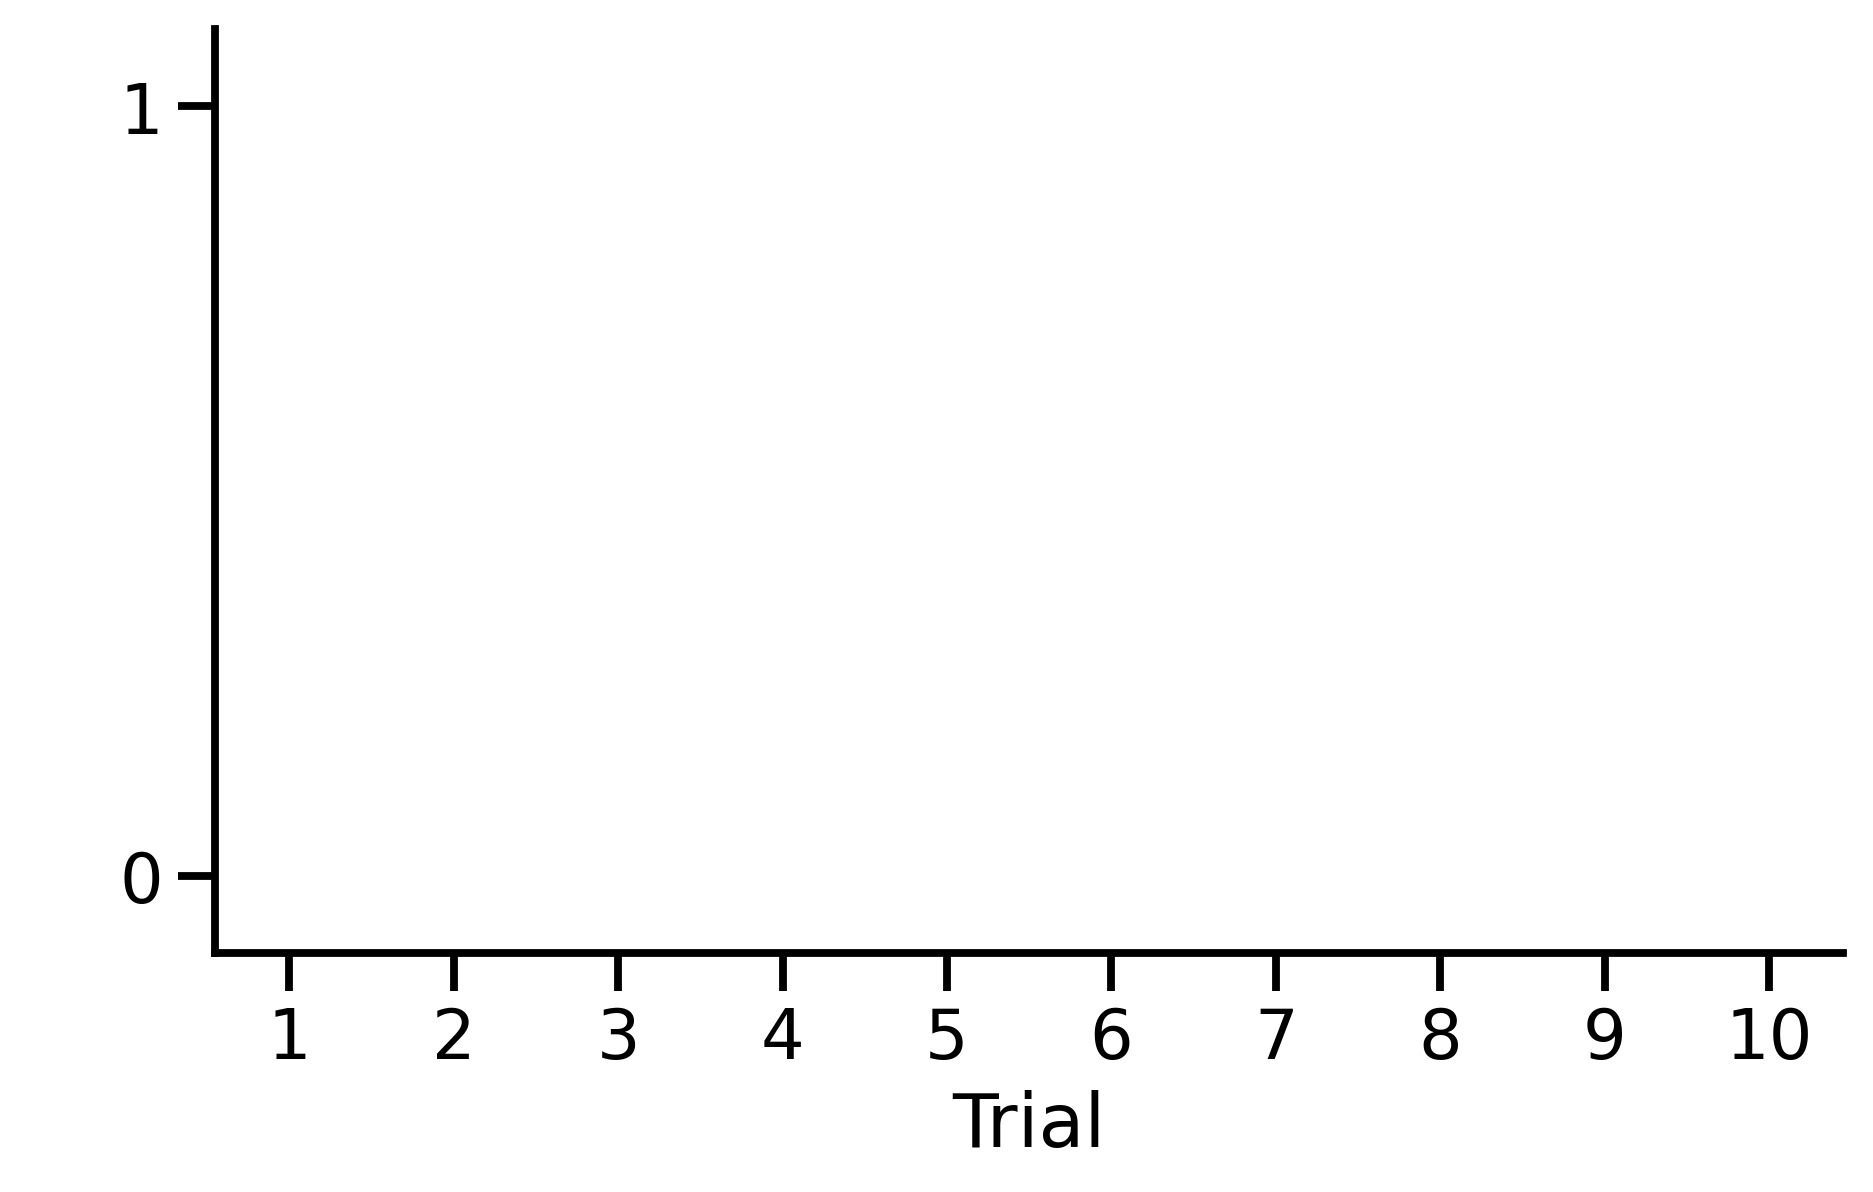

In [21]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=300) 

vddf = demo_data.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.1), color="white", marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color="white", linestyle='--', linewidth=2)

sns.lineplot(x=demo_data["trial"], y=demo_data["prev_violation"], drawstyle='steps-mid', label="Binary\nPrev Violation", ax=ax, color="white", linewidth=4, marker="o", zorder=0)

ax.legend().remove()
ax.set(
    ylabel=" ",
    xlabel="Trial",
    ylim=ylim
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10
ax.set_yticks(np.arange(0,2))

sns.despine()


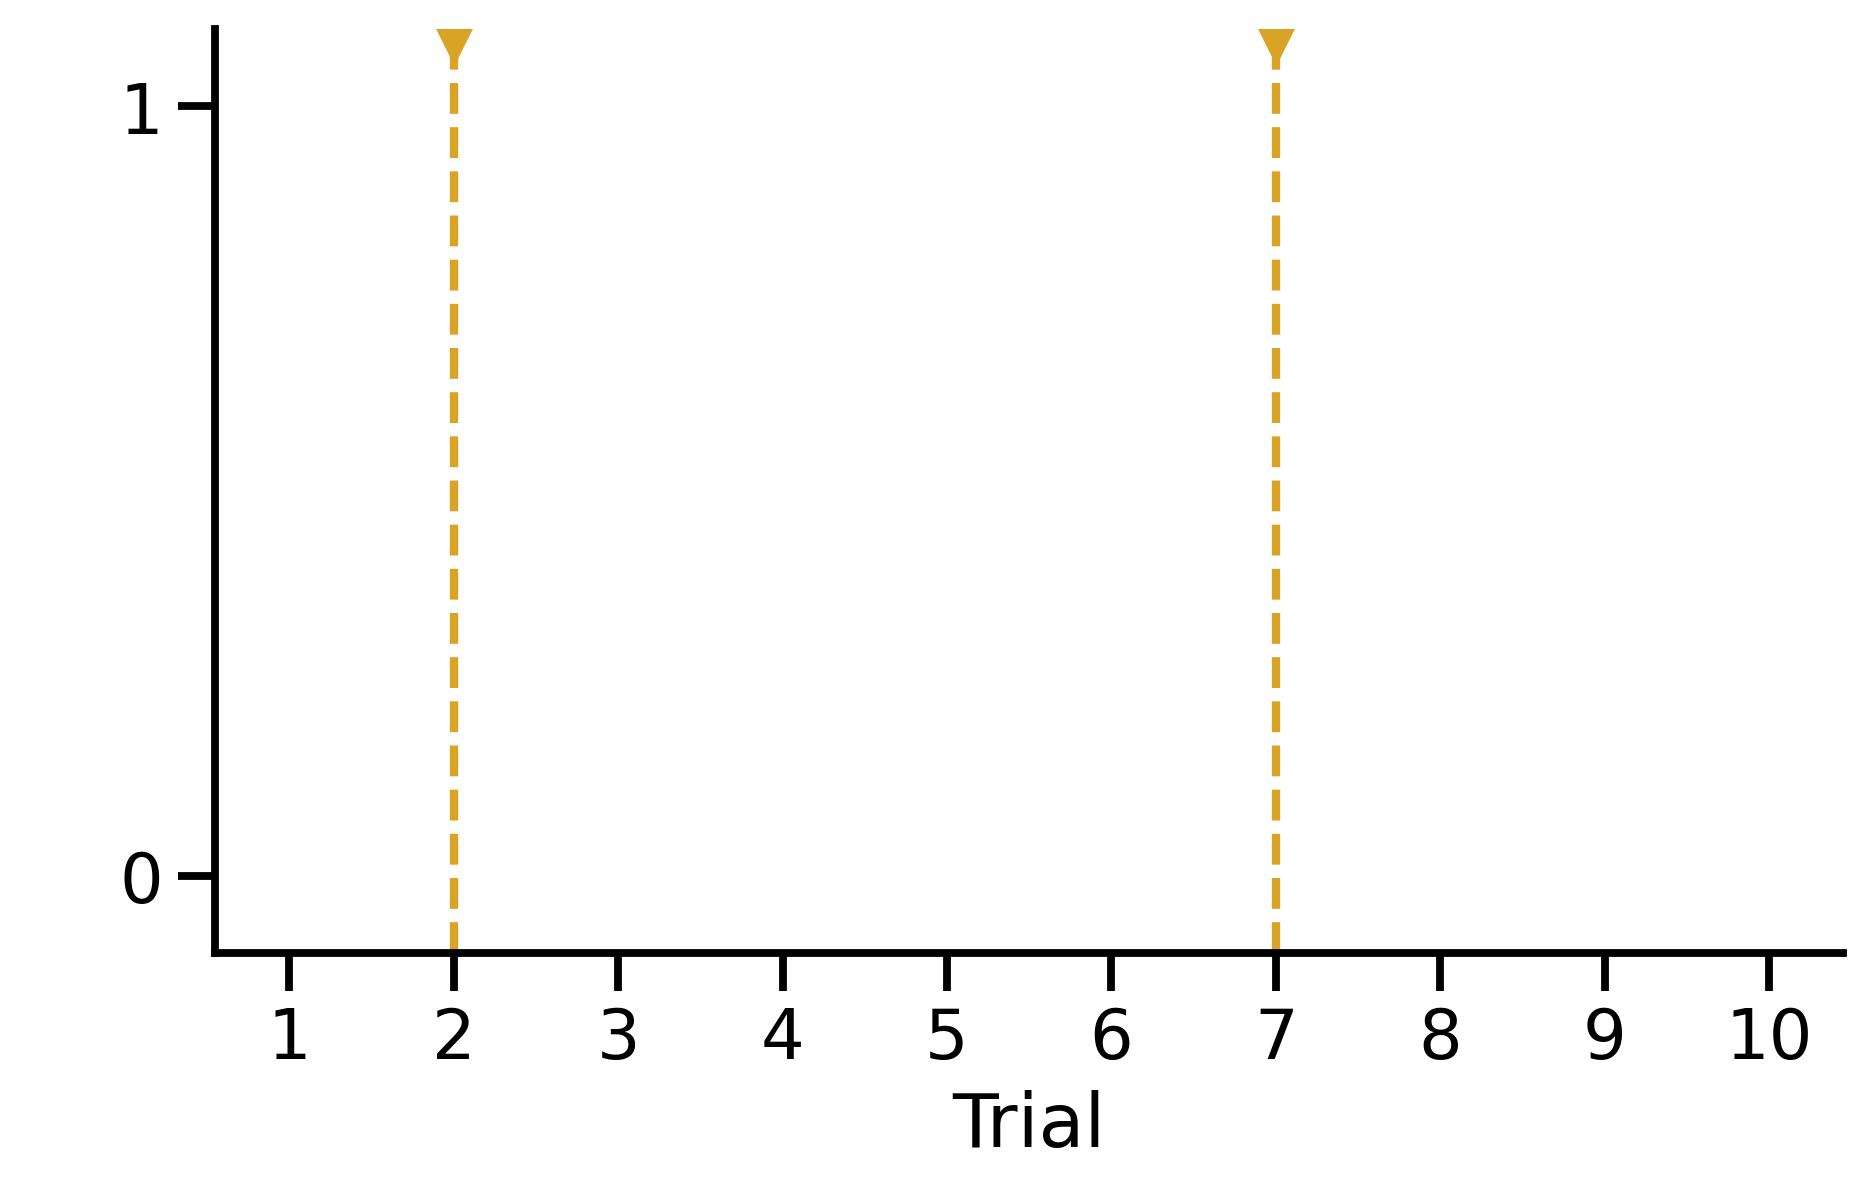

In [22]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=300) 

vddf = demo_data.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.1), color=c.VIOLATION_COLOR_FPO, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR_FPO, linestyle='--', linewidth=2)

sns.lineplot(x=demo_data["trial"], y=demo_data["prev_violation"], drawstyle='steps-mid', label="Binary\nPrev Violation", ax=ax, color="white", linewidth=4, marker="o", zorder=0)

ax.legend().remove()
ax.set(
    ylabel=" ",
    xlabel="Trial",
    ylim=ylim
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10
ax.set_yticks(np.arange(0,2))
sns.despine()


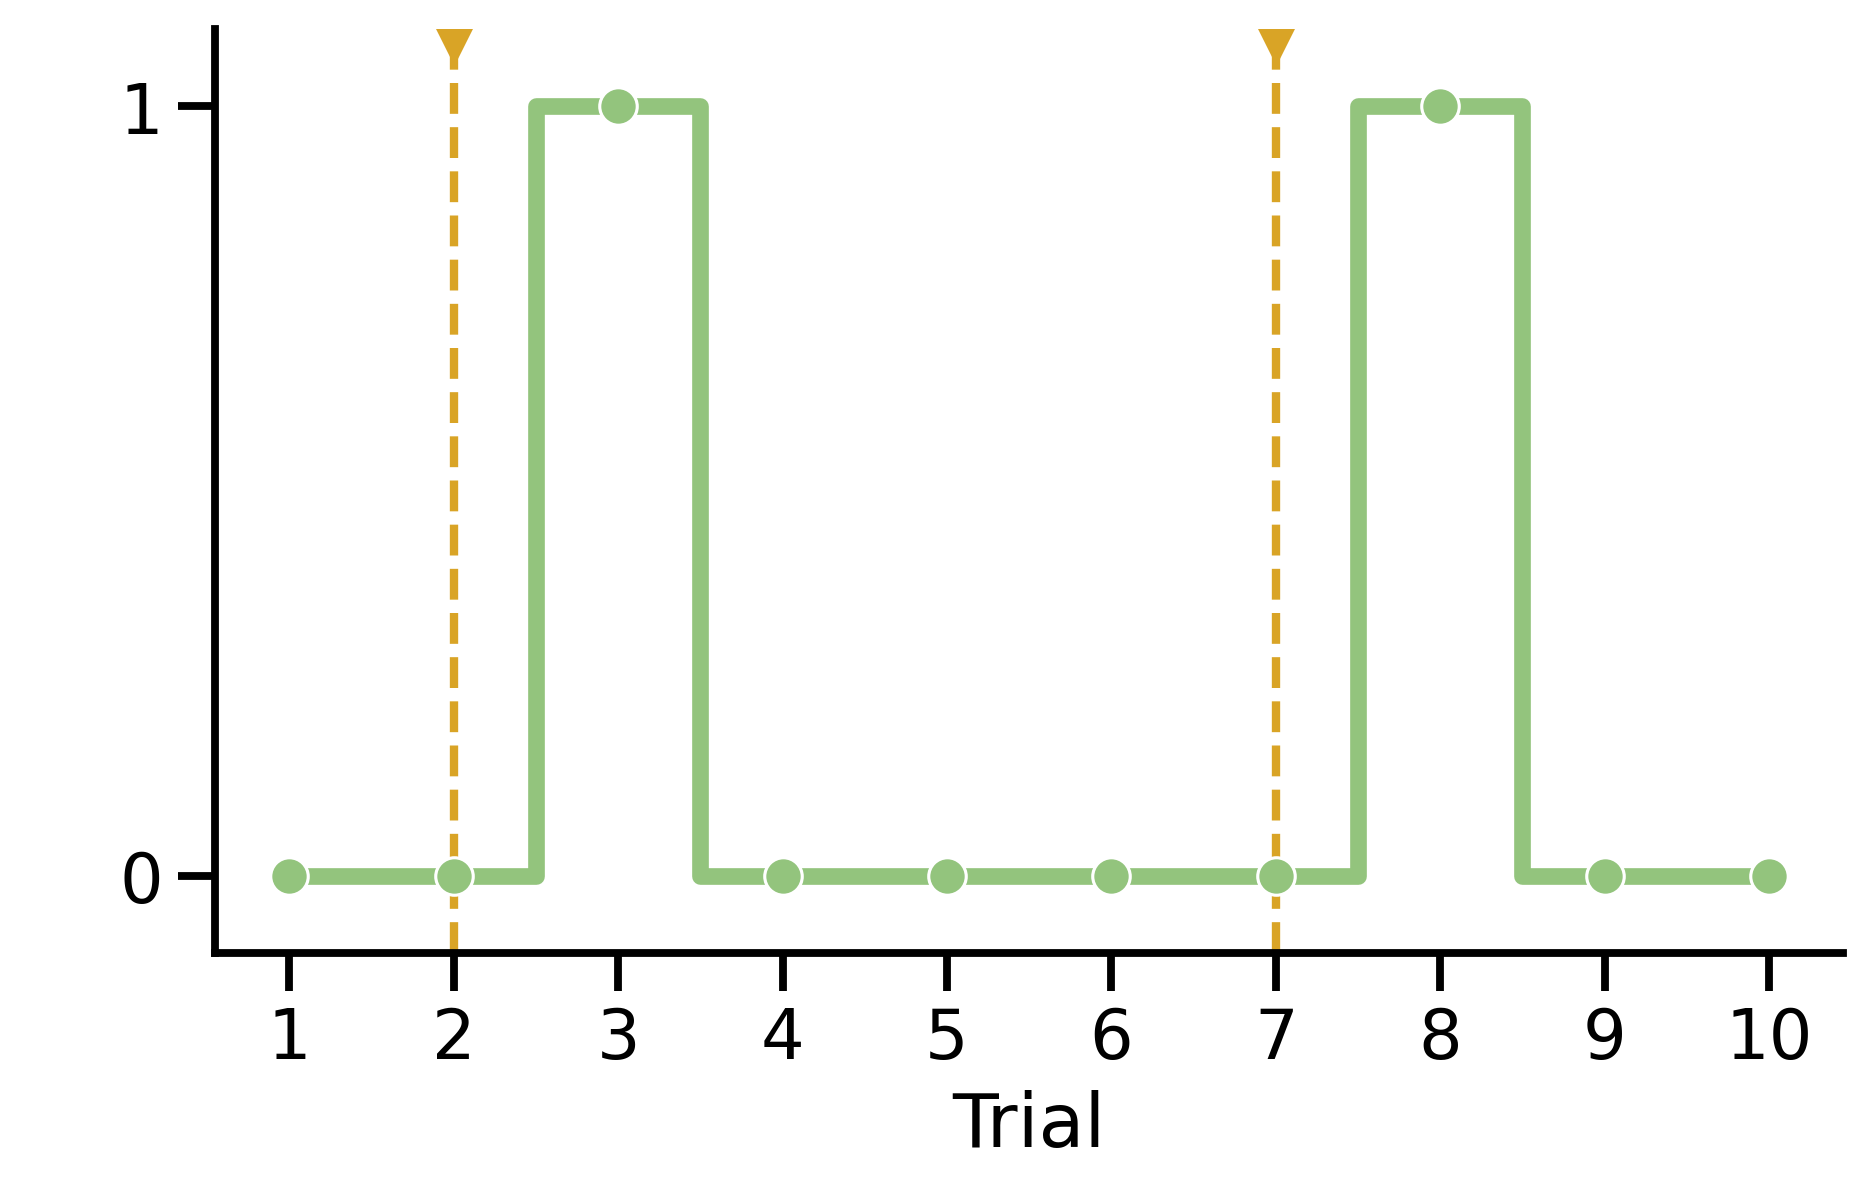

In [25]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=300) 

vddf = demo_data.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.1), color=c.VIOLATION_COLOR_FPO, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR_FPO, linestyle='--', linewidth=2)

sns.lineplot(x=demo_data["trial"], y=demo_data["prev_violation"], drawstyle='steps-mid', label="Binary\nPrev Violation", ax=ax, color=c.PREV_VIOLATION_COLOR, linewidth=4, marker="o")

ax.legend().remove()
ax.set_xlabel("Trial")
ax.set_ylabel(" ")
ax.set_ylim(ylim)
ax.set_yticks(np.arange(0,2))

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()


In [13]:
kernel = ExpFilter(tau=1).create_kernel()

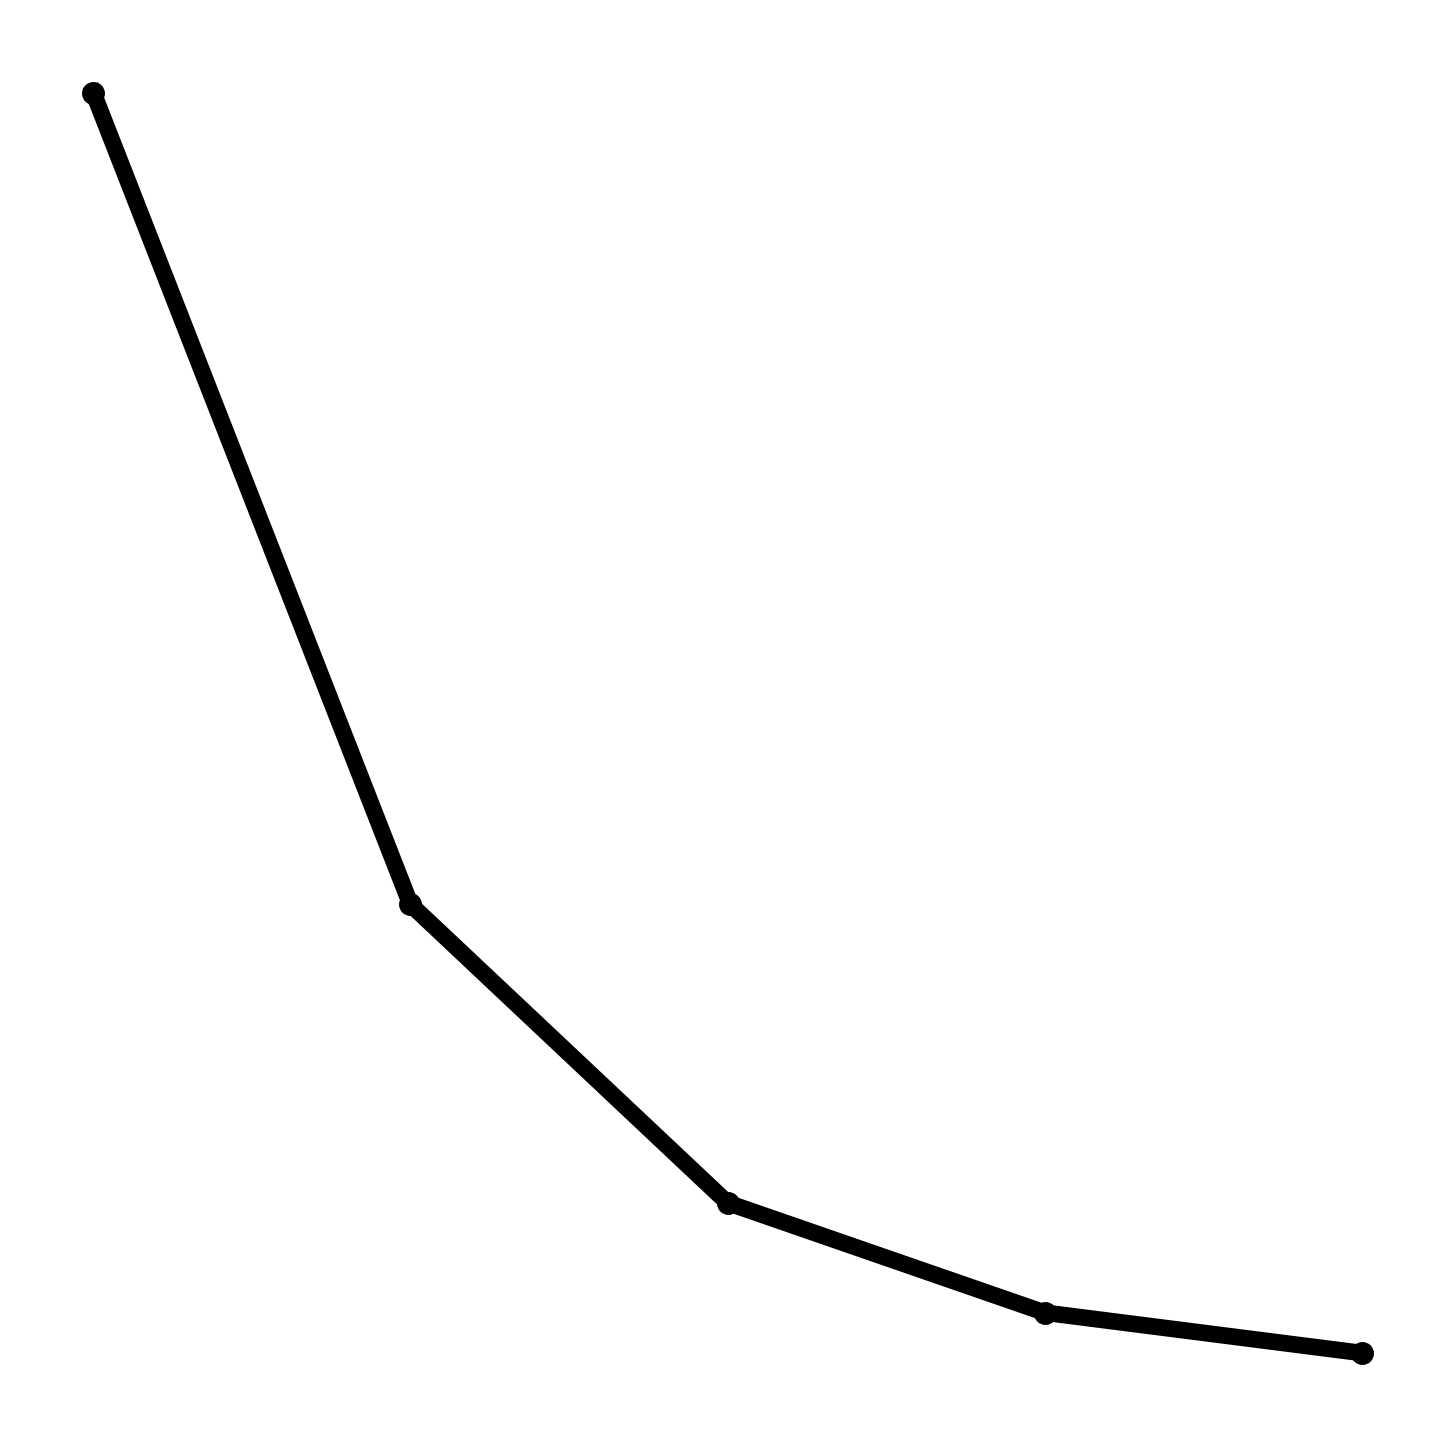

In [14]:
kernel = ExpFilter(tau=1).create_kernel()
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
plt.plot(kernel, color="k", marker=".", linewidth=4)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)


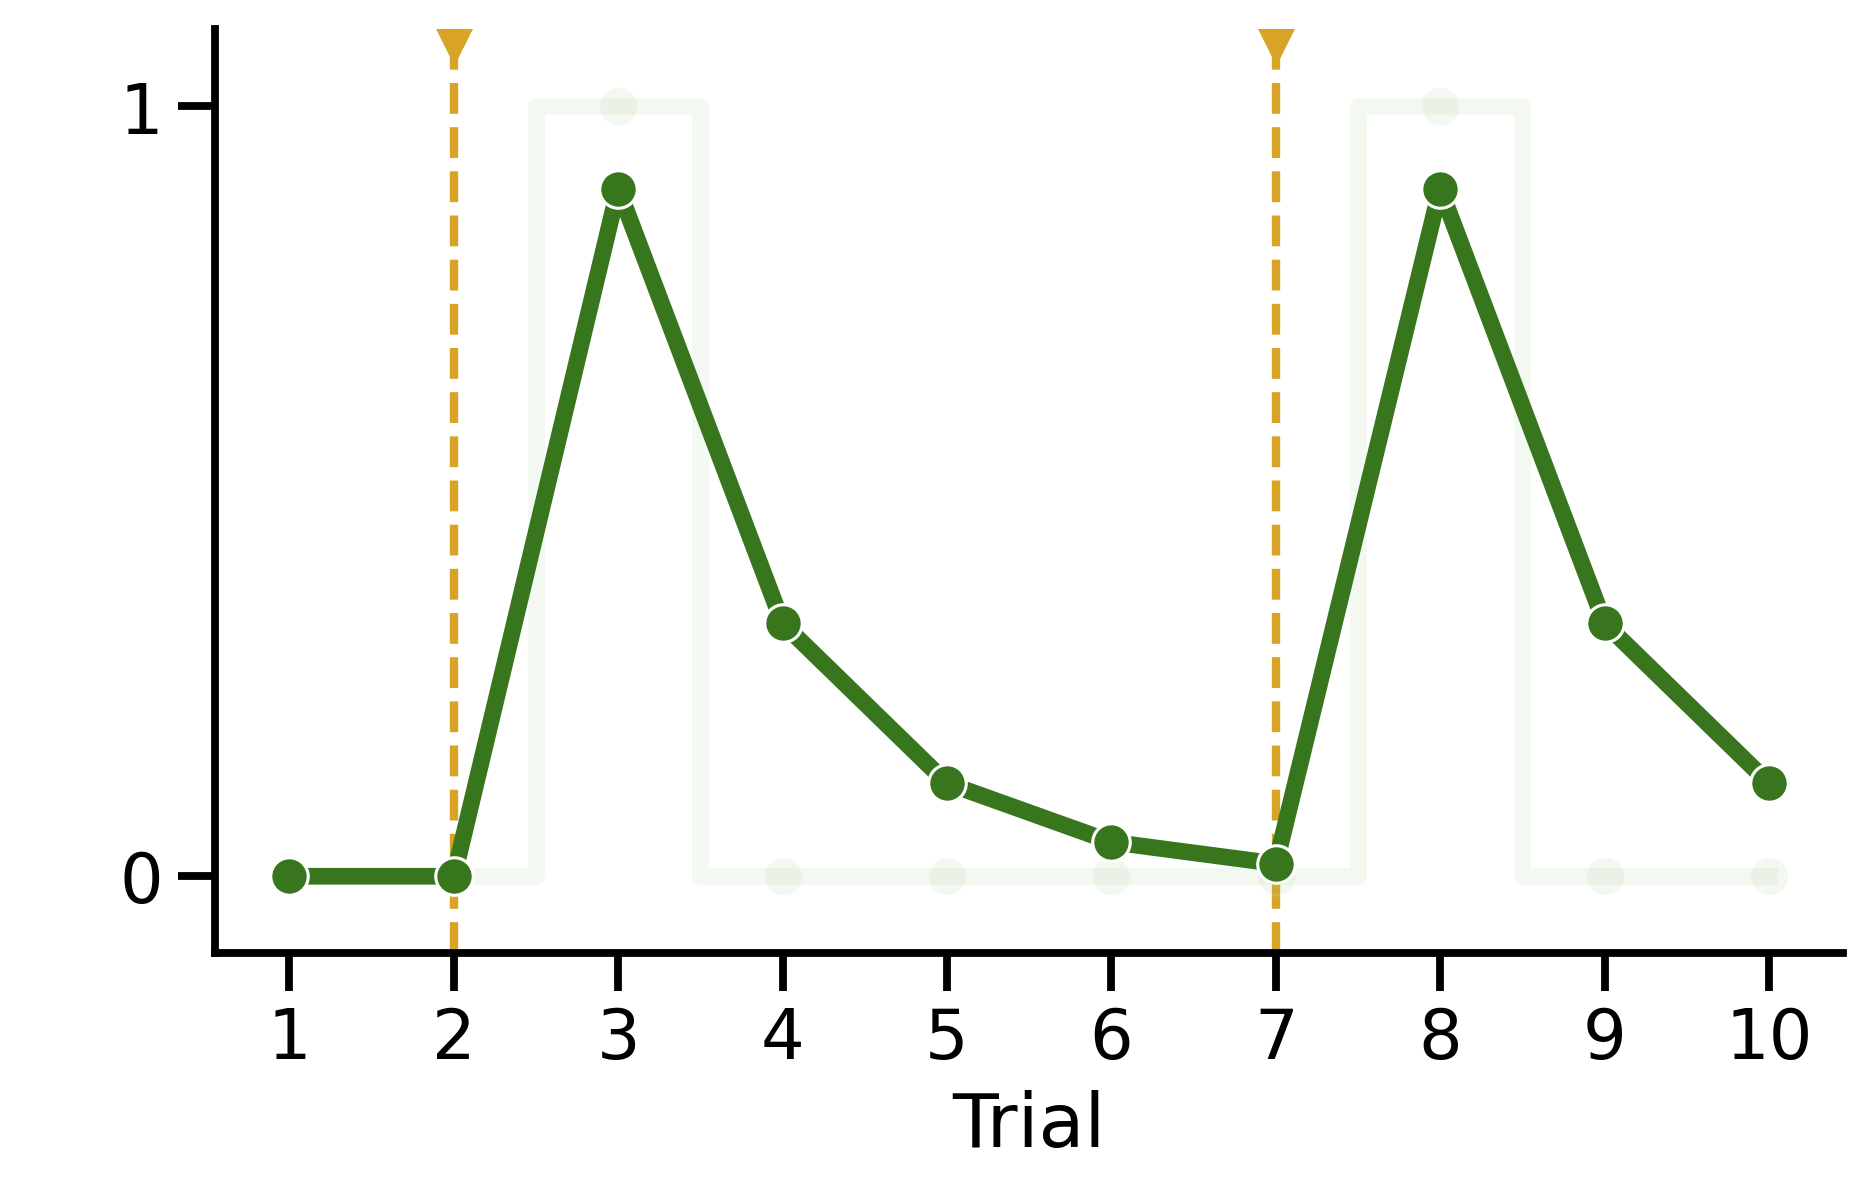

In [28]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=300) 

vddf = demo_data.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.1), color=c.VIOLATION_COLOR_FPO, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR_FPO, linestyle='--', linewidth=2)

sns.lineplot(x=demo_data["trial"], y=demo_data["prev_violation"], drawstyle='steps-mid', label="Binary\nPrev Violation", ax=ax, color=c.PREV_VIOLATION_COLOR, linewidth=4, marker="o", alpha=0.10)


sns.lineplot(x=demo_data["trial"], y=demo_data["prev_violation_exp_tau1"], label="", ax=ax, color=c.PREV_VIOLATION_FILTER_COLOR, linewidth=4, marker="o")

ax.legend().remove()
ax.set_xlabel("Trial")
ax.set_ylabel(" ")
ax.set_ylim(ylim)
ax.set_yticks(np.arange(0,2))
ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()


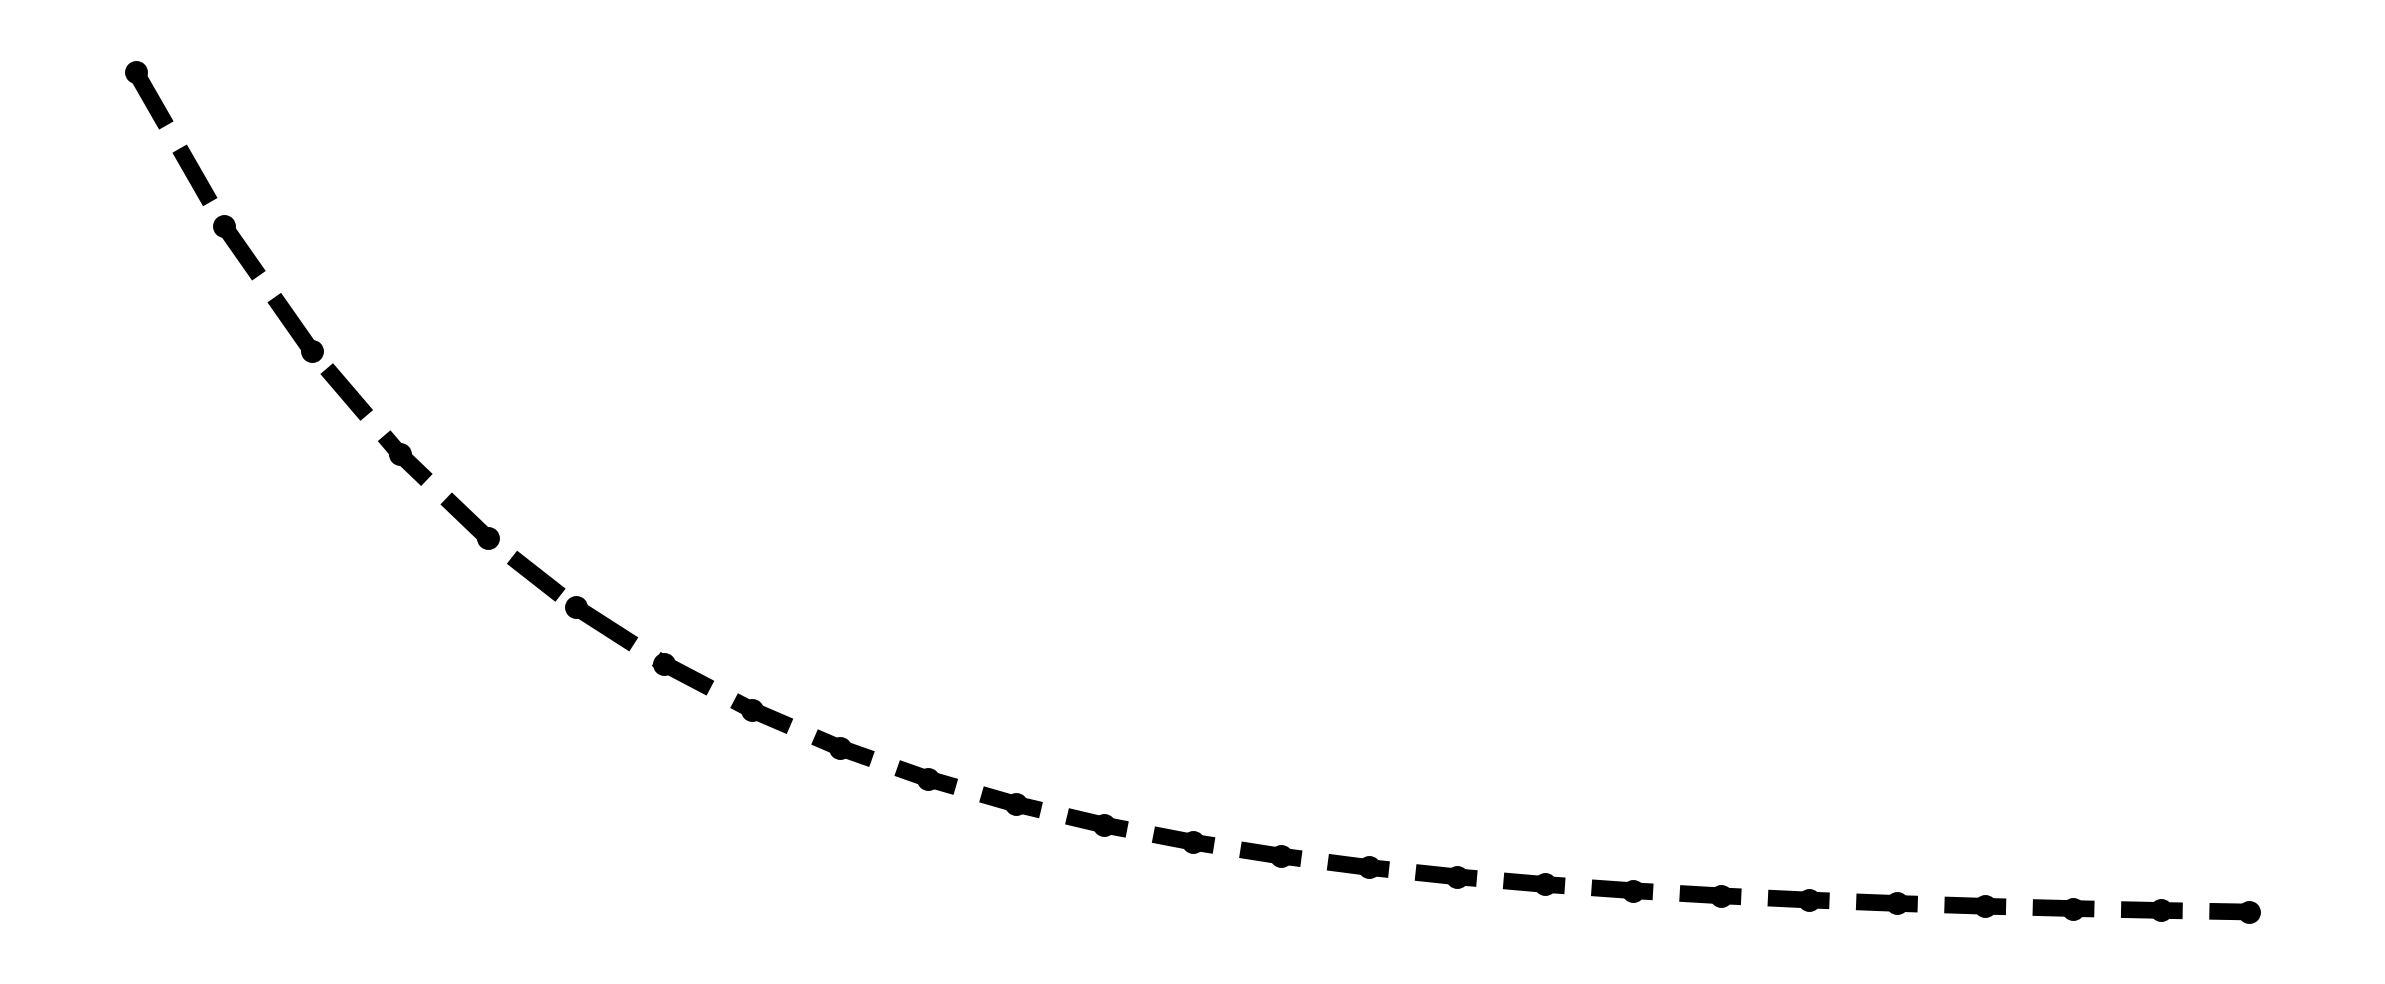

In [ ]:


kernel = ExpFilter(tau=5).create_kernel()
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
plt.plot(kernel, color="k", marker=".", linewidth=4, linestyle="--")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)


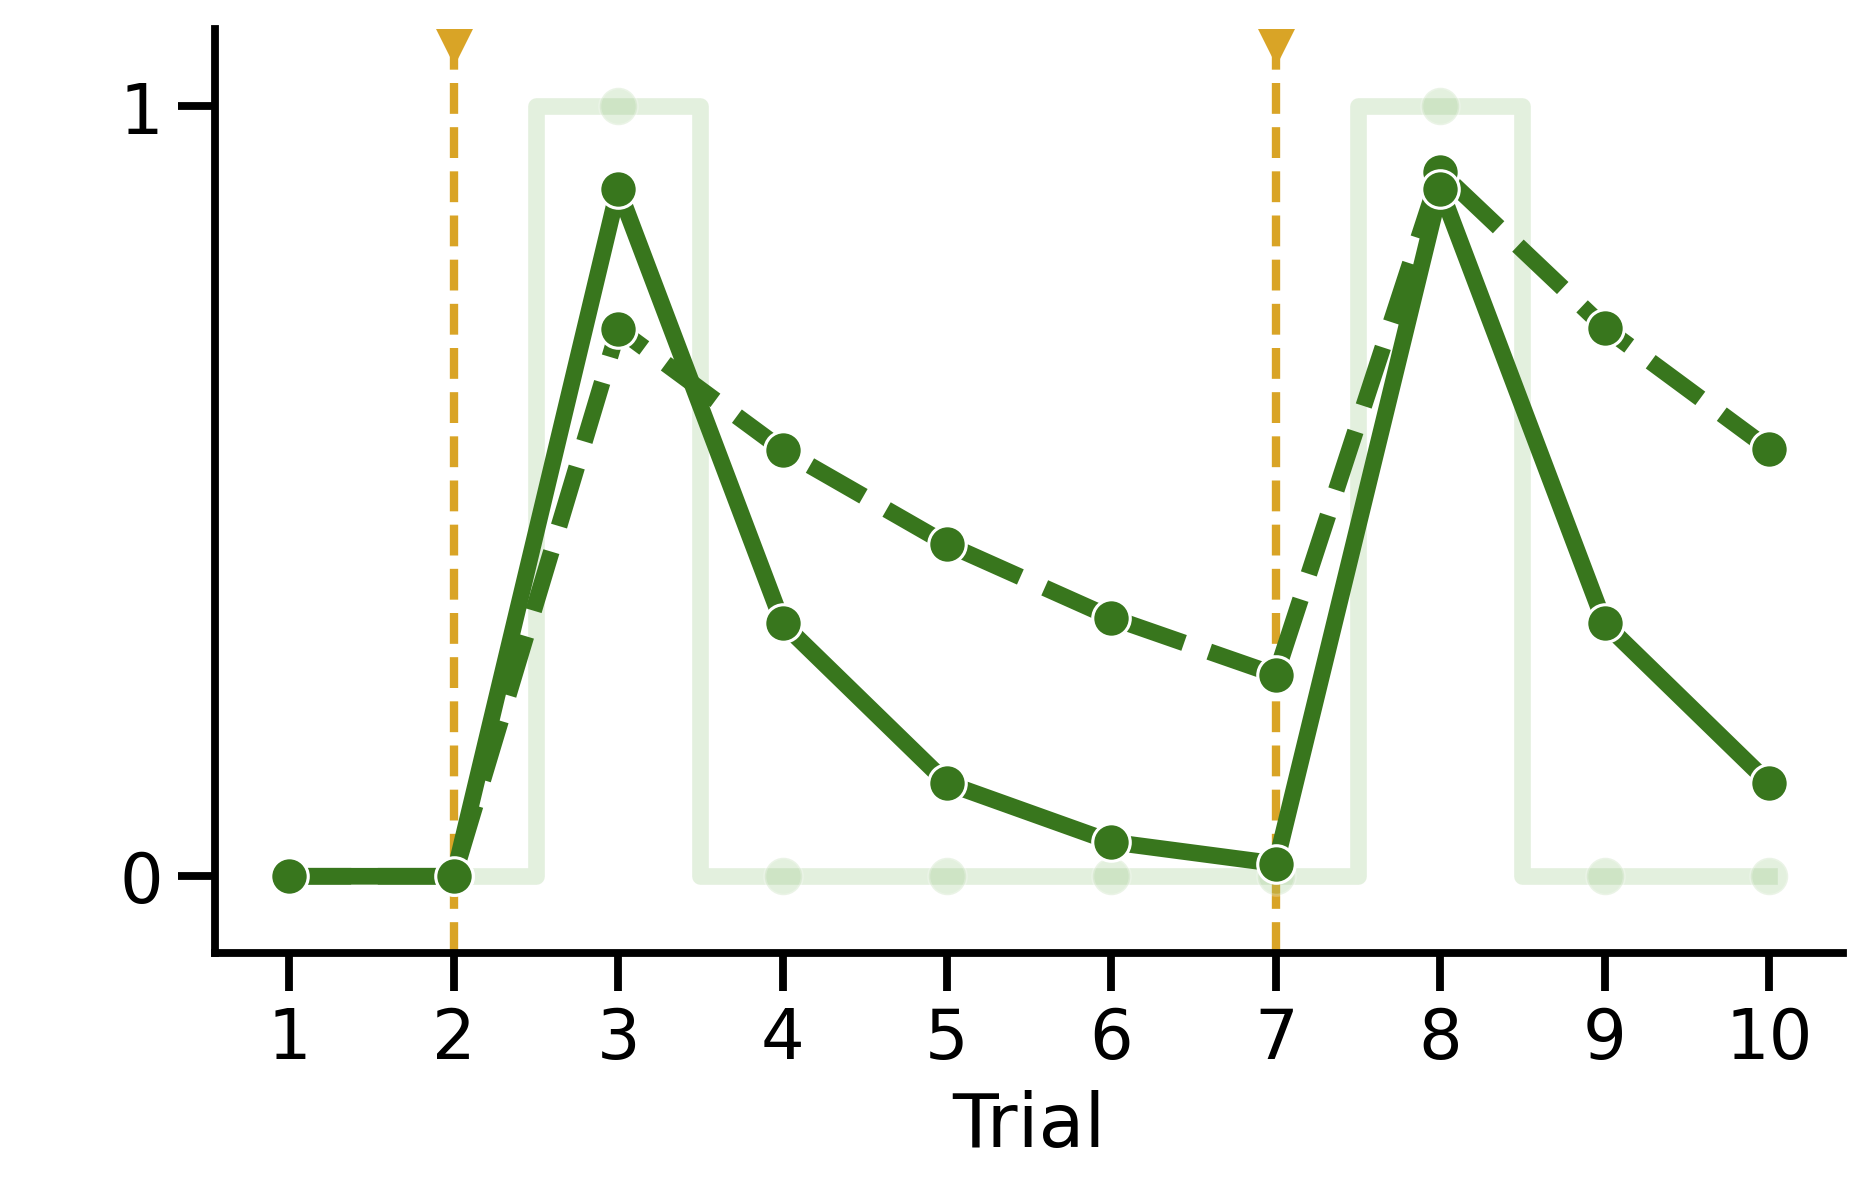

In [38]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=300) 

vddf = demo_data.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.1), color=c.VIOLATION_COLOR_FPO, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR_FPO, linestyle='--', linewidth=2)

sns.lineplot(x=demo_data["trial"], y=demo_data["prev_violation"], drawstyle='steps-mid', label="Binary\nPrev Violation", ax=ax, color=c.PREV_VIOLATION_COLOR, linewidth=4, marker="o", alpha=0.25)

sns.lineplot(x=demo_data["trial"], y=demo_data["prev_violation_exp_tau4"], label="", ax=ax, color=c.PREV_VIOLATION_FILTER_COLOR, linewidth=4, marker="o", linestyle="--")

sns.lineplot(x=demo_data["trial"], y=demo_data["prev_violation_exp_tau1"], label="", ax=ax, color=c.PREV_VIOLATION_FILTER_COLOR, linewidth=4, marker="o")


ax.legend().remove()
ax.set(
    ylabel=" ",
    xlabel="Trial",
    ylim=ylim
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10
ax.set_yticks(np.arange(0,2))

sns.despine()


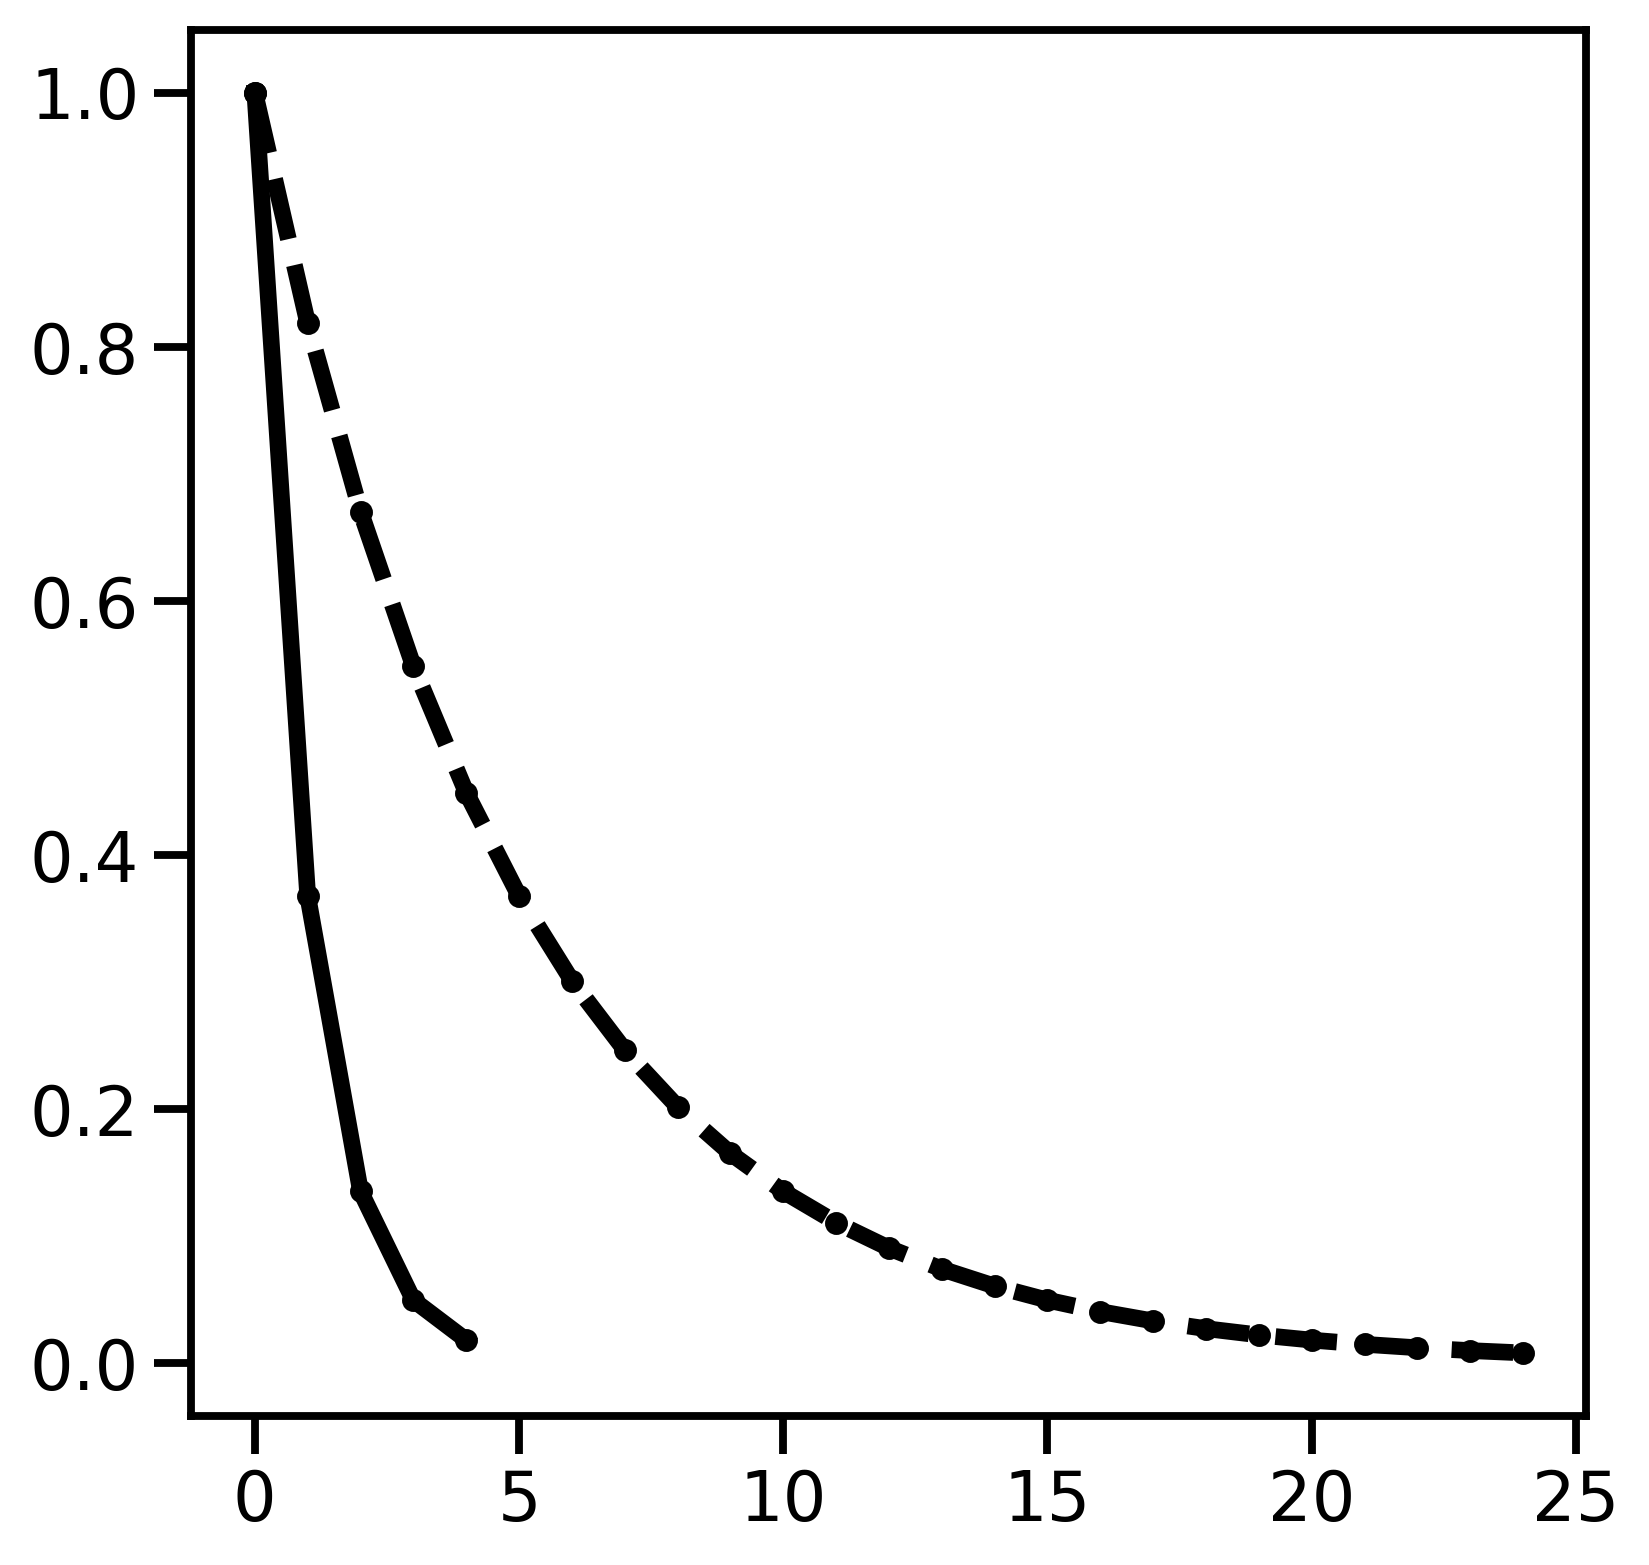

In [102]:

kernel = ExpFilter(tau=1).create_kernel()
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
plt.plot(kernel, color="k", marker=".", linewidth=4)

kernel2 = ExpFilter(tau=5).create_kernel()
plt.plot(kernel2, color="k", marker=".", linewidth=4, linestyle="--")


## Weights


In [48]:
mvpv = ModelVisualizer(load_experiment(filt_prev_viol_exp))
df = mvpv.unpack_features_and_weights()
df.feature.unique()

features = ["filt_prev_violation", "s_a","s_b",]
weight_class = 'V'
df = df.query("feature in @features and weight_class == @weight_class").copy()

YMIN=-2.1
YMAX=2.1

LABELS = [
    "Recent\nViolation\nHistory",
    "Sound 1\nLoudness", 
    "Sound 2\nLoudness",
]

COLORS = [
    "darkgreen",
    "k",
    "k",
]




/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:508: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  sns.pointplot(


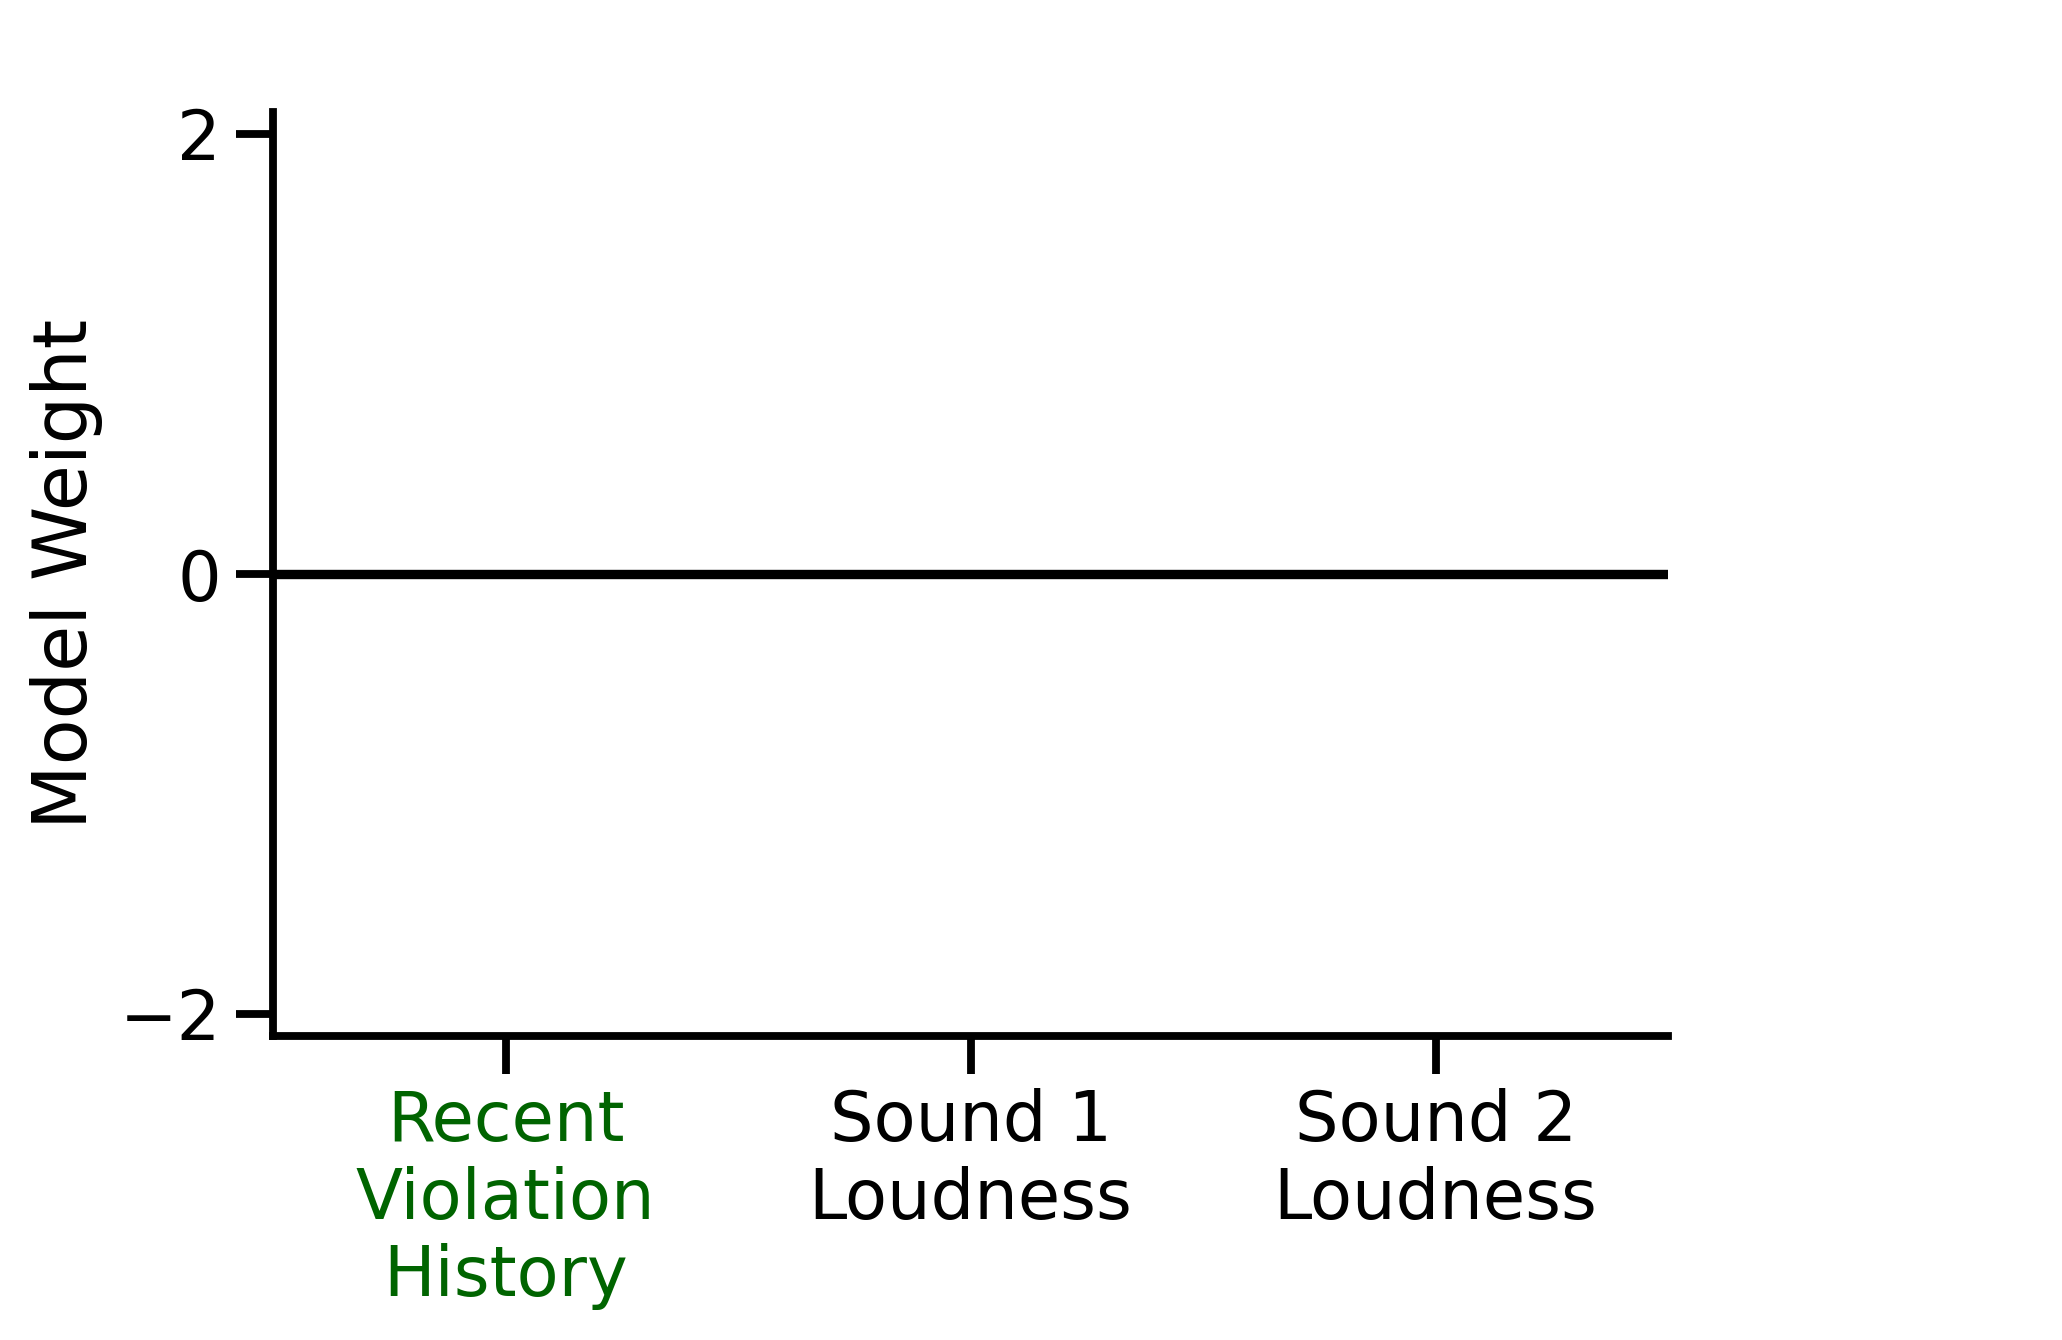

In [47]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300) 

palette = ["#FFFFFF", "#FFFFFF", "#FFFFFF"]

mvpv.plot_weights_summary(df=df, ax=ax,style="point", plot_bias = False, title=" ", plot_individuals=False, seed=19, palette=palette,errorbar="se")

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False)
for text in legend.get_texts():
    text.set_color("white")

# set x labels
ax.set_xticks(range(len(LABELS)))
_ = ax.set_xticklabels(LABELS, rotation=0,)
tick_labels = ax.get_xticklabels()
for label, color in zip(tick_labels, COLORS):
    label.set_color(color)

ax.set_ylabel("Model Weight", color="k")
ax.set_ylim(YMIN, YMAX)
ax.set_yticks([-2, 0, 2])


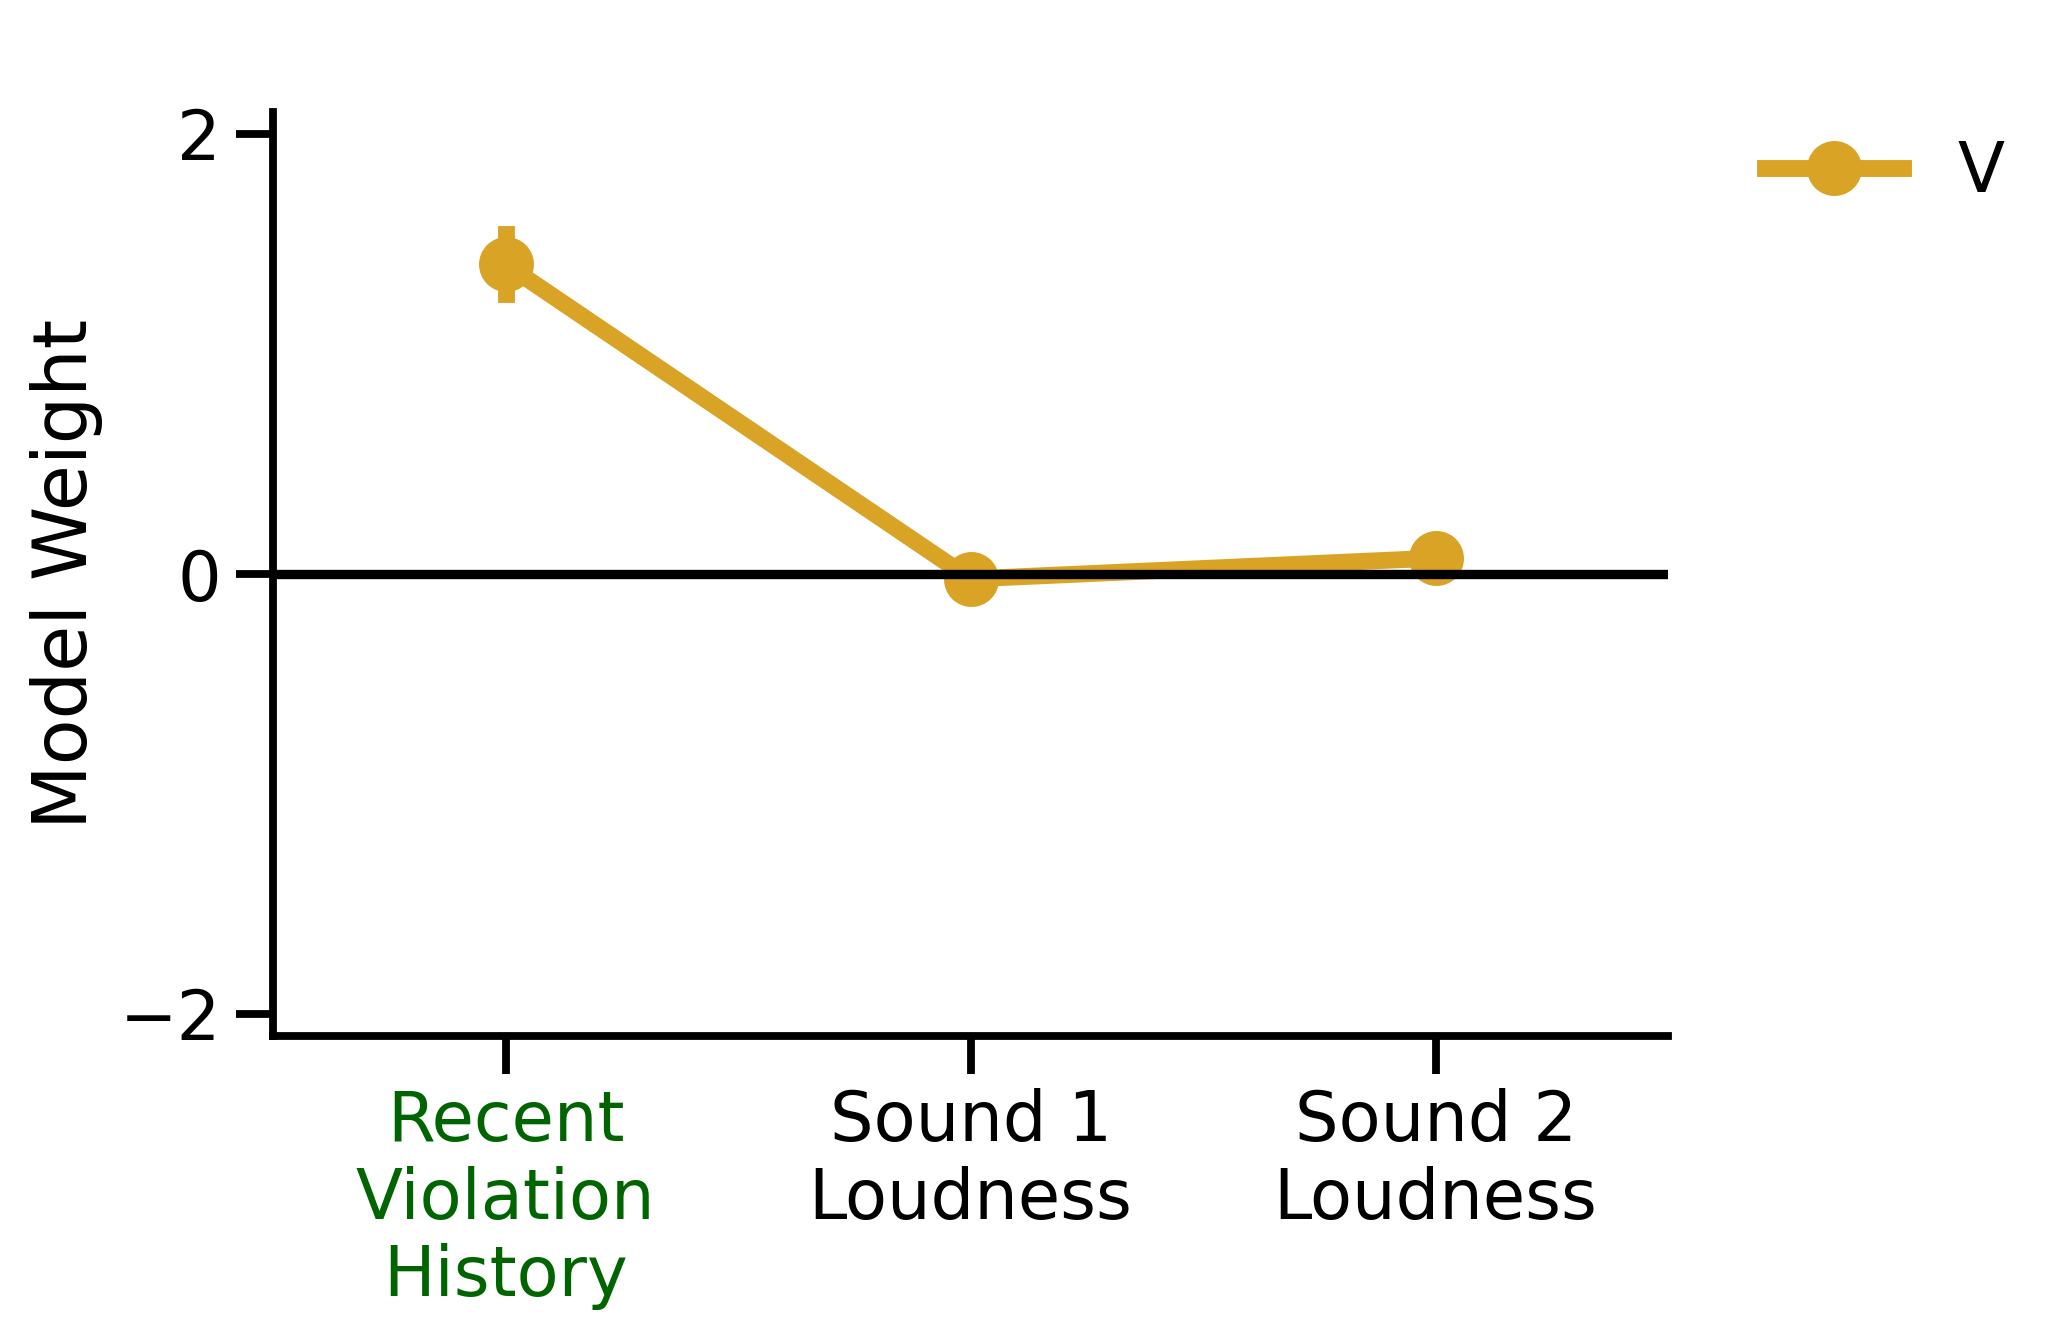

In [50]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300) 

palette = [c.VIOLATION_COLOR_FPO]

mvpv.plot_weights_summary(df=df, ax=ax,style="point", plot_bias = False, title=" ", plot_individuals=False, seed=19, palette=palette,errorbar="se", order=features)

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False)

# set x labels
ax.set_xticks(range(len(LABELS)))
_ = ax.set_xticklabels(LABELS, rotation=0,)
tick_labels = ax.get_xticklabels()
for label, color in zip(tick_labels, COLORS):
    label.set_color(color)

ax.set_ylabel("Model Weight", color="k")
ax.set_ylim(YMIN, YMAX)
ax.set_yticks([-2, 0, 2])


## Compare


In [134]:
mvc = ModelVisualizerCompare(load_experiment(compare_exp))

ORDER = [
    "base",
    "prev_viol_filtered",
]
LABELS = [
    "Baseline",
    "Violation\nHistory"
]
COLORS = [
    "k",
    "darkgreen",
]

bits_per_trial_df = mvc.compute_bits_per_trial_df()
bits_per_trial_df.model_name.unique()

bits_per_trial_df = bits_per_trial_df.query("model_name == 'base' or model_name == 'prev_viol_filtered'")

[Text(0.5, 0, ''), Text(0.5, 1.0, '')]

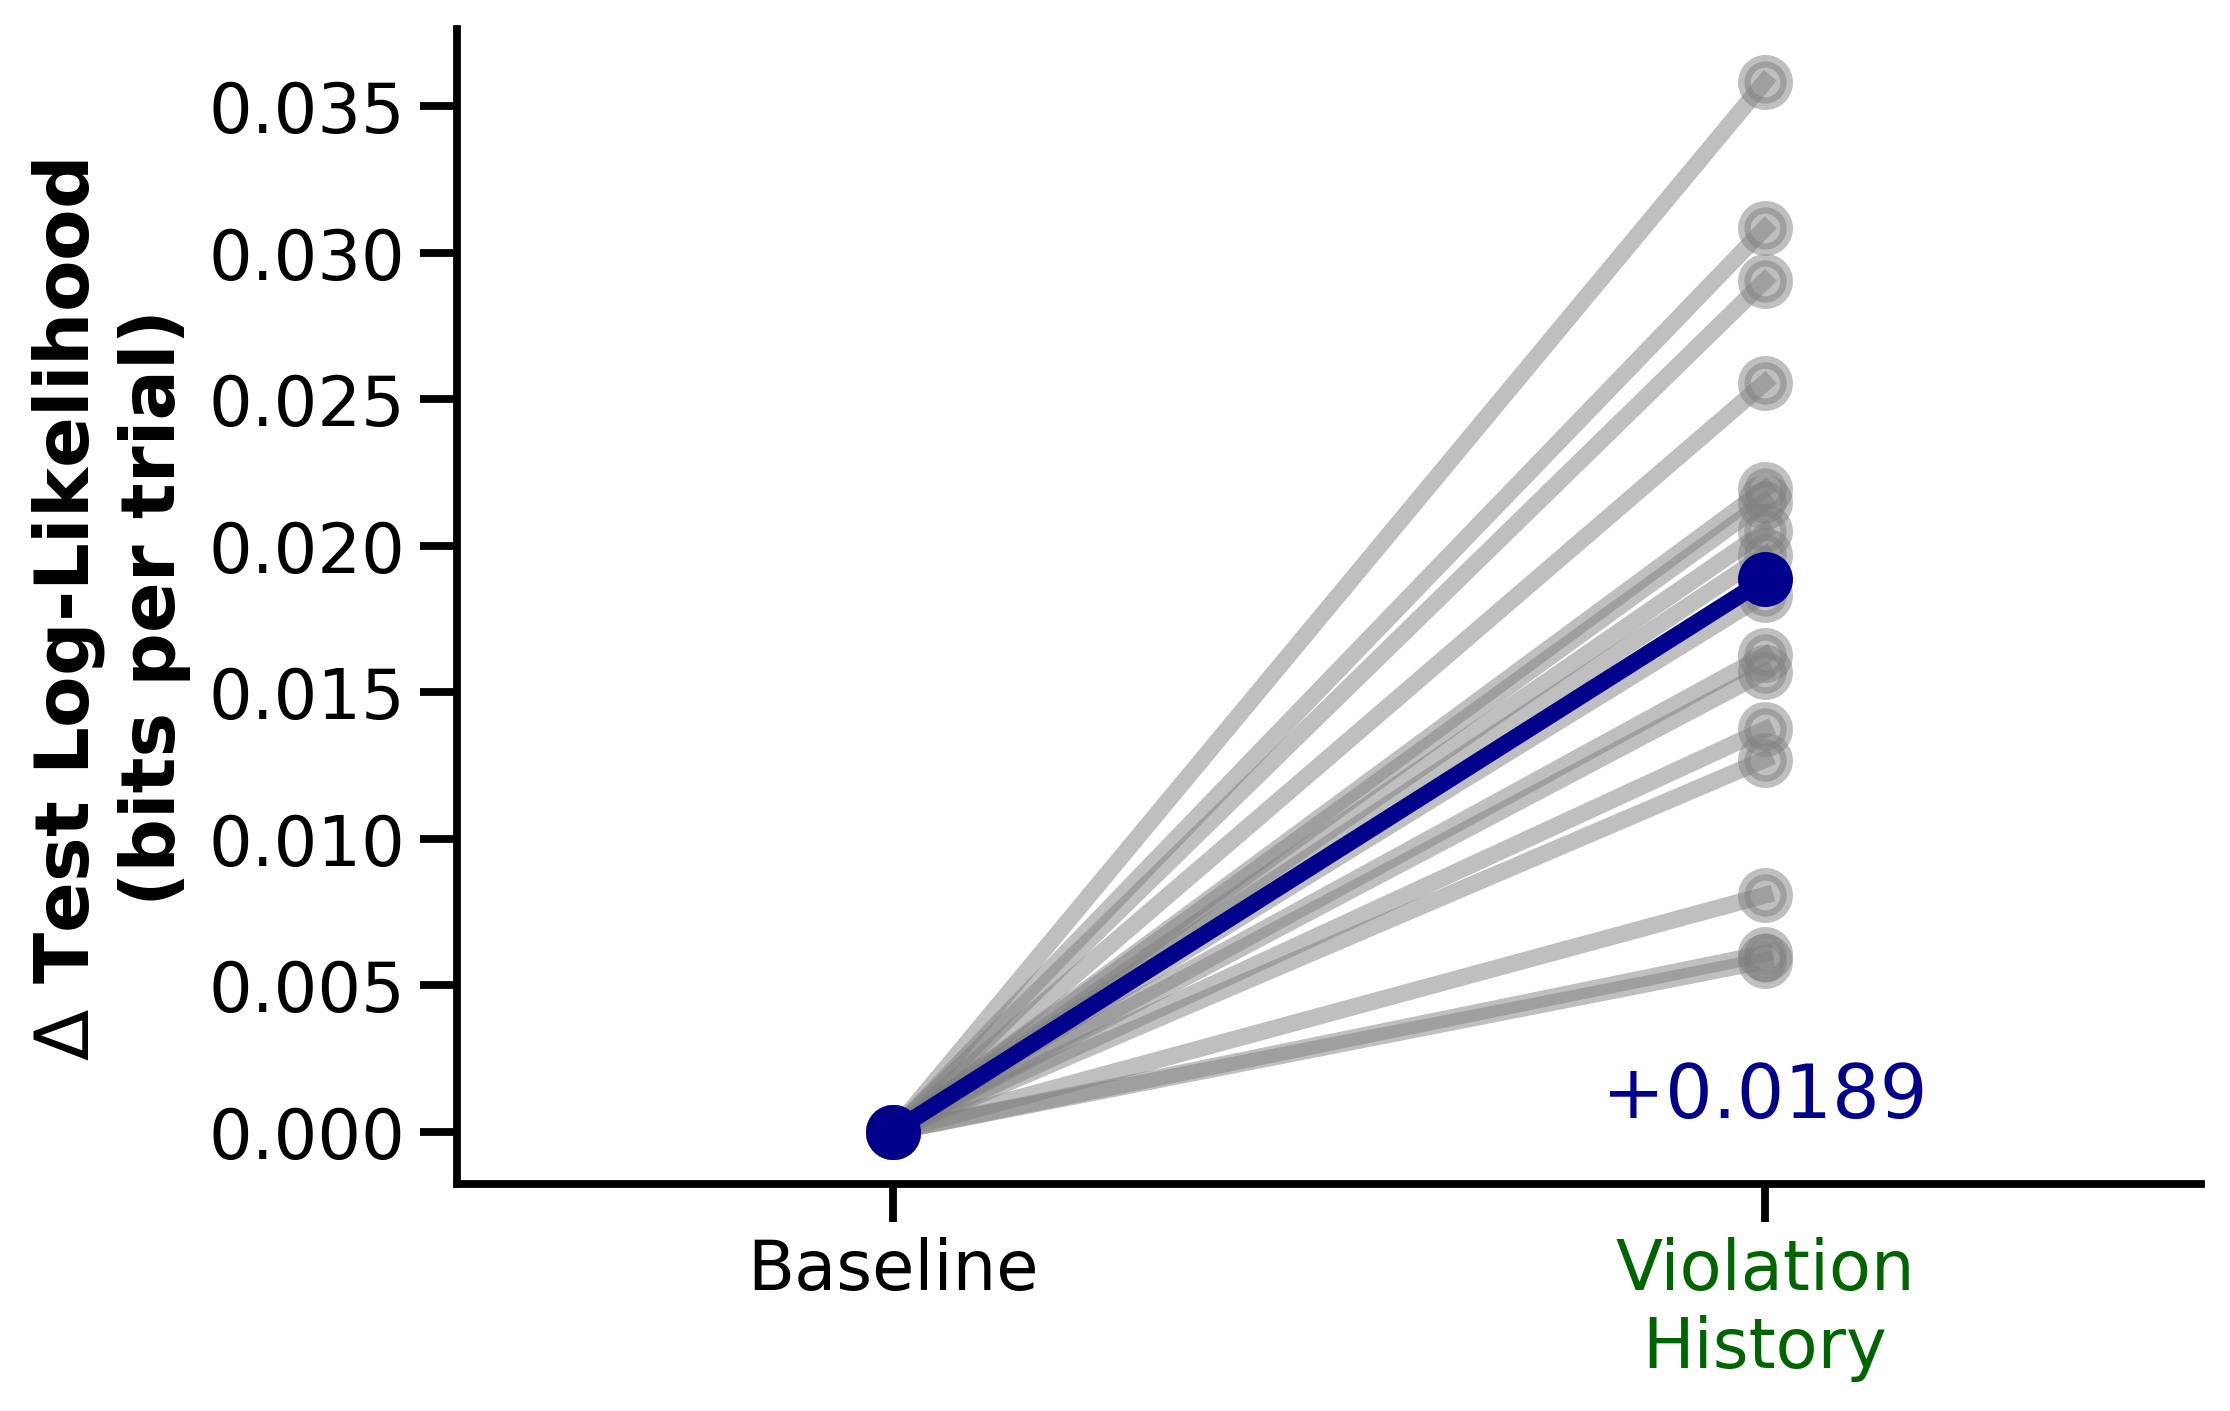

In [142]:
fig, ax = plt.subplots(figsize=(7.5, 5), dpi=300)
sns.despine()
mvc.plot_model_comparison(
    bits_per_trial_df,
    hue="animal_id",
    ax=ax,
    order=ORDER,
    palette=["gray"] * 16,
    alpha = 0.5,
    y="bits_per_trial_relative_to_base"
)
mvc.plot_model_comparison(
    bits_per_trial_df,
    ax=ax,
    order=ORDER,
    color=c.MODEL_COMPARE_COLOR,
    errorbar=None,
    y="bits_per_trial_relative_to_base",
    ylabel="$\Delta$ Test Log-Likelihood \n(bits per trial)",
    annotate=True,
    y_annotate=0.0005,
    color_annotate=c.MODEL_COMPARE_COLOR
)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=0)
tick_labels = ax.get_xticklabels()
for label, color in zip(tick_labels, COLORS):
    label.set_color(color)

ax.set_ylabel("$\Delta$ Test Log-Likelihood \n(bits per trial)", fontweight="bold")
ax.legend().remove()
ax.set(xlabel="", title="")
